**Analyse et modélisation du dataset FAO (Food and agriculture Organization).**

# ⚙️ SETUP

## IMPORTS

### Standards

In [3]:
import os
import warnings
from pathlib import Path

### Externals

In [ ]:
# Data
import numpy as np
import pandas as pd

# Viz
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyBboxPatch
import plotly.graph_objects as go
import plotly.express as px


# ML
import sklearn as sk
from sklearn import (
    compose,
    cluster,
    dummy,
    decomposition,
    ensemble,
    linear_model,
    metrics,
    model_selection,
    pipeline,
    preprocessing,
)
import xgboost as xgb

# Other
from tqdm_joblib import tqdm_joblib

## OPTIONS

### Warnings

In [4]:
warnings.filterwarnings("ignore")

### Pandas

In [5]:
pd.options.display.max_rows = None
pd.options.display.max_columns = None

### Matplotlib

In [6]:
PALETTE = [
    "#2ecc71",
    "#3498db",
    "#e74c3c",
    "#f39c12",
    "#9b59b6",
    "#1abc9c",
    "#e67e22",
    "#34495e",
    "#e91e63",
    "#00bcd4",
]
BG_COLOR = "#0f1117"
CARD_COLOR = "#1a1d27"
TEXT_COLOR = "#edf2f7"
ACCENT = "#2ecc71"

plt.rcParams.update(
    {
        "figure.facecolor": BG_COLOR,  # Couleur de fond globale
        "axes.facecolor": CARD_COLOR,  # Couleur de fond du graphique
        "axes.edgecolor": "#2d3748",  # Couleur des bordures
        "axes.labelcolor": TEXT_COLOR,  # Couleur des titres des axes X/Y
        "axes.titlecolor": TEXT_COLOR,  # Couleur du titre du graphique
        "xtick.color": TEXT_COLOR,  # Couleur des valeurs sur l"axe X
        "ytick.color": TEXT_COLOR,  # Couleur des valeurs sur l"axe Y
        "text.color": TEXT_COLOR,  # Couleur par defaut des textes
        "grid.color": "#2d3748",  # Couleur de la grille
        "grid.linestyle": "--",  # Grille en pointilles
        "grid.alpha": 0.5,  # Grille semi-transparente
        "font.family": "Arial",  # Police d"ecriture utilisee
        "axes.spines.top": False,  # Masque la bordure superieure
        "axes.spines.right": False,  # Masque la bordure droite
    }
)

### Sklearn

In [7]:
sk.set_config(transform_output="pandas")

## CONFIGS

### Seeds

In [8]:
RANDOM = 42
np.random.seed(RANDOM)

### Folders

In [9]:
ROOT = Path("../")
DATA = ROOT / "data"
CACHE = ROOT / ".cache"
PLOTS = ROOT / "notebooks" / "plots"

### Datasets

In [10]:
YIELD_GEN = DATA / "crop_yield.csv"

FAO = DATA / "Crop Yield Prediction Dataset"

PESTICIDES = FAO / "pesticides.csv"
RAINFALL = FAO / "rainfall.csv"
TEMPERATURE = FAO / "temp.csv"
YIELD = FAO / "yield.csv"
YIELD_FAO = FAO / "yield_df.csv"

CSV_FILES = sorted(DATA.rglob("*.csv"))

### Columns

In [11]:
TARGET = "yield"

### Sampling

In [12]:
RAW_NROWS = None  # set an integer for faster iterations, e.g. 100_000.
SAMPLE_ROWS = 100_000

### Splittings

In [13]:
SPLITS = 4
SHUFFLE = False  # required (time sensitive).
TEST_YEAR_START = 2010


### Searchings

In [14]:
SCORING = "neg_root_mean_squared_error"
N_ITER = 20
PARAM_GRID_RIDGE = {
    "regressor__alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
}
PARAM_GRID_RF = {
    "regressor__max_depth": [10, 15, None],
    "regressor__n_estimators": [100, 200],
}
PARAM_GRID_XGB = {
    # Profondeur de l'arbre : 4 (faible), 6 (standard), 8 ou 10 (capte les sous-groupes complexes pays/cultures).
    "regressor__max_depth": [4, 6, 8, 10],
    # Taux d'apprentissage : 0.03 (lent/précis), 0.05, 0.1 (standard).
    "regressor__learning_rate": [0.03, 0.05, 0.1],
    # Nombre d'arbres.
    "regressor__n_estimators": [150, 300, 500],
    # Sous-échantillonnage (empoche l'overfitting).
    "regressor__subsample": [0.8, 1.0],
    "regressor__colsample_bytree": [0.8, 1.0],
}


## DATASETS

### Files

In [15]:
def count_data_rows(path: Path) -> int:
    with path.open("rb") as file:
        return max(sum(1 for _ in file) - 1, 0)


inventory = pd.DataFrame(
    [
        {
            "file": str(path.relative_to(DATA)),
            "size_mb": path.stat().st_size / 1024**2,
            "rows": count_data_rows(path),
        }
        for path in CSV_FILES
    ]
).sort_values(by="file")

inventory


,file,size_mb,rows
0,Crop Yield Prediction Dataset/pesticides.csv,0.426938,4349
1,Crop Yield Prediction Dataset/rainfall.csv,0.130379,6727
2,Crop Yield Prediction Dataset/temp.csv,1.355566,71311
3,Crop Yield Prediction Dataset/yield.csv,3.855642,56717
4,Crop Yield Prediction Dataset/yield_df.csv,1.492859,28242
5,crop_yield.csv,89.080825,1000000


### Loading

In [24]:
def read_clean_csv(path: Path, **kwargs) -> pd.DataFrame:
    dataset = pd.read_csv(path, **kwargs)
    dataset.columns = dataset.columns.str.strip()
    unnamed = [col for col in dataset.columns if col.startswith("Unnamed:")]
    return dataset.drop(columns=unnamed)


# Generated dataset
gen = read_clean_csv(YIELD_GEN, nrows=RAW_NROWS).rename(
    columns={
        "Region": "region",
        "Soil_Type": "soil",
        "Crop": "crop",
        "Yield_tons_per_hectare": "yield",
        "Rainfall_mm": "rain",
        "Fertilizer_Used": "fertilizer",
        "Temperature_Celsius": "temp",
        "Irrigation_Used": "irrigation",
        "Weather_Condition": "weather",
        "Days_to_Harvest": "days",
    }
)
gen["yield"] = gen["yield"].astype(float) * 10000

gen["fertilizer"] = gen["fertilizer"].astype(int)
gen["irrigation"] = gen["irrigation"].astype(int)

# FAO Dataset
agri = read_clean_csv(YIELD_FAO).rename(
    columns={
        "Area": "country",
        "Item": "crop",
        "hg/ha_yield": "yield",
        "average_rain_fall_mm_per_year": "rain",
        "pesticides_tonnes": "pest",
        "avg_temp": "temp",
        "Year": "year",
    }
)

pesticides = read_clean_csv(PESTICIDES)
rainfall = read_clean_csv(RAINFALL)
temperature = read_clean_csv(TEMPERATURE)
yield_raw = read_clean_csv(YIELD)


datasets = {
    "gen": gen,
    "agri": agri,
    "pesticides": pesticides,
    "rainfall": rainfall,
    "temperature": temperature,
    "yield": yield_raw,
}

for name, dataset in datasets.items():
    print(f"{name}: {dataset.shape}")
    display(dataset.head())


gen: (1000000, 10)


,region,soil,crop,rain,temp,fertilizer,irrigation,weather,days,yield
0,West,Sandy,Cotton,897.077239,27.676966,0,1,Cloudy,122,65558.162582
1,South,Clay,Rice,992.673282,18.026142,1,1,Rainy,140,85273.409063
2,North,Loam,Barley,147.998025,29.794042,0,0,Sunny,106,11274.433360
3,North,Sandy,Soybean,986.866331,16.644190,0,1,Rainy,146,65175.725076
4,South,Silt,Wheat,730.379174,31.620687,1,1,Cloudy,110,72482.512184


agri: (28242, 7)


,country,crop,year,yield,rain,pest,temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


pesticides: (4349, 7)


,Domain,Area,Element,Item,Year,Unit,Value
0,Pesticides Use,Albania,Use,Pesticides (total),1990,tonnes of active ingredients,121.0
1,Pesticides Use,Albania,Use,Pesticides (total),1991,tonnes of active ingredients,121.0
2,Pesticides Use,Albania,Use,Pesticides (total),1992,tonnes of active ingredients,121.0
3,Pesticides Use,Albania,Use,Pesticides (total),1993,tonnes of active ingredients,121.0
4,Pesticides Use,Albania,Use,Pesticides (total),1994,tonnes of active ingredients,201.0


rainfall: (6727, 3)


,Area,Year,average_rain_fall_mm_per_year
0,Afghanistan,1985,327
1,Afghanistan,1986,327
2,Afghanistan,1987,327
3,Afghanistan,1989,327
4,Afghanistan,1990,327


temperature: (71311, 3)


,year,country,avg_temp
0,1849,Côte D'Ivoire,25.58
1,1850,Côte D'Ivoire,25.52
2,1851,Côte D'Ivoire,25.67
3,1852,Côte D'Ivoire,NaN
4,1853,Côte D'Ivoire,NaN


yield: (56717, 12)


,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1961,1961,hg/ha,14000
1,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1962,1962,hg/ha,14000
2,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1963,1963,hg/ha,14260
3,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1964,1964,hg/ha,14257
4,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1965,1965,hg/ha,14400


### Agri

In [87]:
agri.info()

<class 'pandas.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   country  28242 non-null  str    
 1   crop     28242 non-null  str    
 2   year     28242 non-null  int64  
 3   yield    28242 non-null  int64  
 4   rain     28242 non-null  float64
 5   pest     28242 non-null  float64
 6   temp     28242 non-null  float64
dtypes: float64(3), int64(2), str(2)
memory usage: 1.5 MB


In [133]:
print(f"\n📅 Year range  : {agri.year.min()} – {agri.year.max()}")
print(f"🌍 Countries   : {agri.country.nunique()}")
print(
    f"🌱 Crop types  : {agri.crop.nunique()} : {', '.join(sorted(agri['crop'].unique()))}"
)
print(f"🌡️ Temp range : {agri.temp.min()} – {agri.temp.max()}")
print(f"🌧️ Rain range : {agri.rain.min()} – {agri.rain.max()}")
print(f"🧪 Pest range : {agri.pest.min()} – {agri.pest.max()}")
print(f"💰 Yield range : {agri['yield'].min()} – {agri['yield'].max()}")
print(f"📐 Total rows  : {len(agri):,}")


📅 Year range  : 1990 – 2013
🌍 Countries   : 101
🌱 Crop types  : 10 : Cassava, Maize, Plantains and others, Potatoes, Rice, paddy, Sorghum, Soybeans, Sweet potatoes, Wheat, Yams
🌡️ Temp range : 1.3 – 30.65
🌧️ Rain range : 51.0 – 3240.0
🧪 Pest range : 0.04 – 367778.0
💰 Yield range : 50 – 501412
📐 Total rows  : 28,242


### Gen

In [48]:
print(f"🌍 Region   : {gen.region.nunique()}")
print(f"🌱 Crop types  : {gen.crop.nunique()}")
print(f"🛘 Soil types  : {gen.soil.nunique()}")
print(f"🌤️ Weather types  : {gen.weather.nunique()}")
print(f"🌡️ Temp range : {gen.temp.min():.2f} – {gen.temp.max():.2f}")
print(f"🌧️ Rain range : {gen.rain.min():.2f} – {gen.rain.max():.2f}")
print(f"💰 Yield range : {gen['yield'].min():.2f} – {gen['yield'].max():.2f}")
print(f"📆 Days range : {gen.days.min()} – {gen.days.max()}")
print(f"🧪 Pest rate : {gen.fertilizer.mean():.2f}")
print(f"🧪 Irrigation rate : {gen.irrigation.mean():.2f}")
print(f"📐 Total rows  : {len(gen):,}")

🌍 Region   : 4
🌱 Crop types  : 6
🛘 Soil types  : 6
🌤️ Weather types  : 3
🌡️ Temp range : 15.00 – 40.00
🌧️ Rain range : 100.00 – 1000.00
💰 Yield range : -11476.13 – 99633.72
📆 Days range : 60 – 149
🧪 Pest rate : 0.50
🧪 Irrigation rate : 0.50
📐 Total rows  : 1,000,000


# 🔎 EXPLORATION

## GEN DATASET

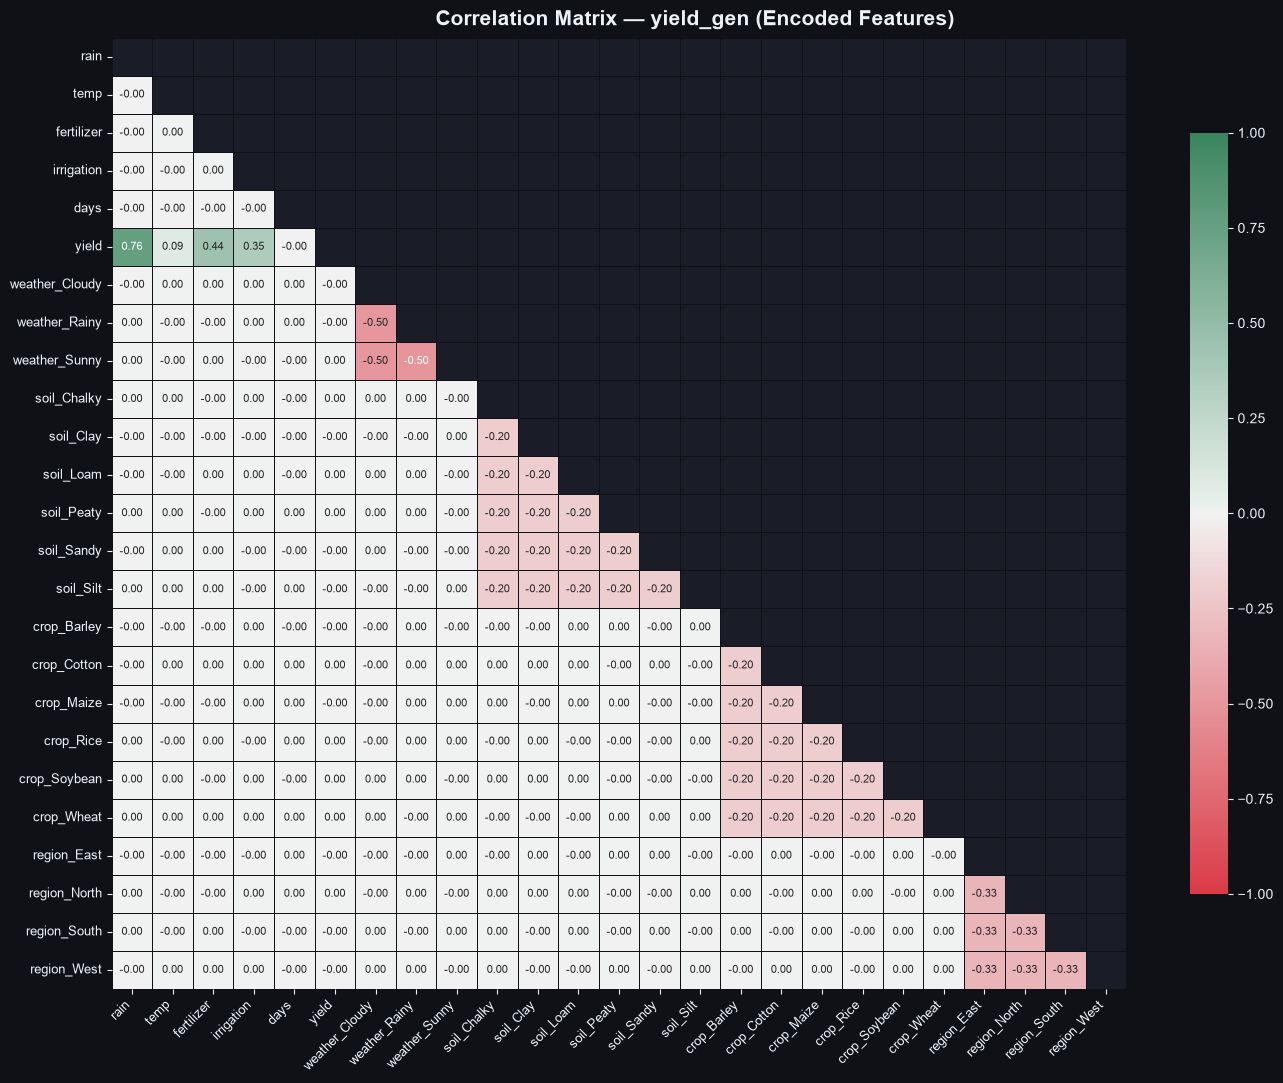

In [94]:
# 1. Préparation des données avec One-Hot Encoding
df_corr = gen.copy()

# Encodage des catégorielles et booléens.
cat_cols = ["weather", "soil", "crop", "region"]

# One-Hot Encoding sur les colonnes catégorielles.
df_encoded = pd.get_dummies(df_corr, columns=cat_cols, drop_first=False)


# 2. Calcul de la matrice de corrélation
corr = df_encoded.corr()

# Masque pour cacher la partie supérieure symétrique.
mask = np.triu(np.ones_like(corr, dtype=bool))

# 3. Visualisation de la Heatmap
fig, ax = plt.subplots(figsize=(14, 11))
fig.suptitle(
    "Correlation Matrix — yield_gen (Encoded Features)",
    fontsize=15,
    fontweight="bold",
    y=0.98,
)
fig.patch.set_facecolor(BG_COLOR)

cmap = sns.diverging_palette(10, 145, as_cmap=True)

sns.heatmap(
    corr,
    ax=ax,
    mask=mask,
    cmap=cmap,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor=BG_COLOR,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 8},
)

ax.tick_params(colors=TEXT_COLOR, labelsize=9)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(
    PLOTS / "fig_corr_heatmap_yield_gen.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR,
)
plt.show()


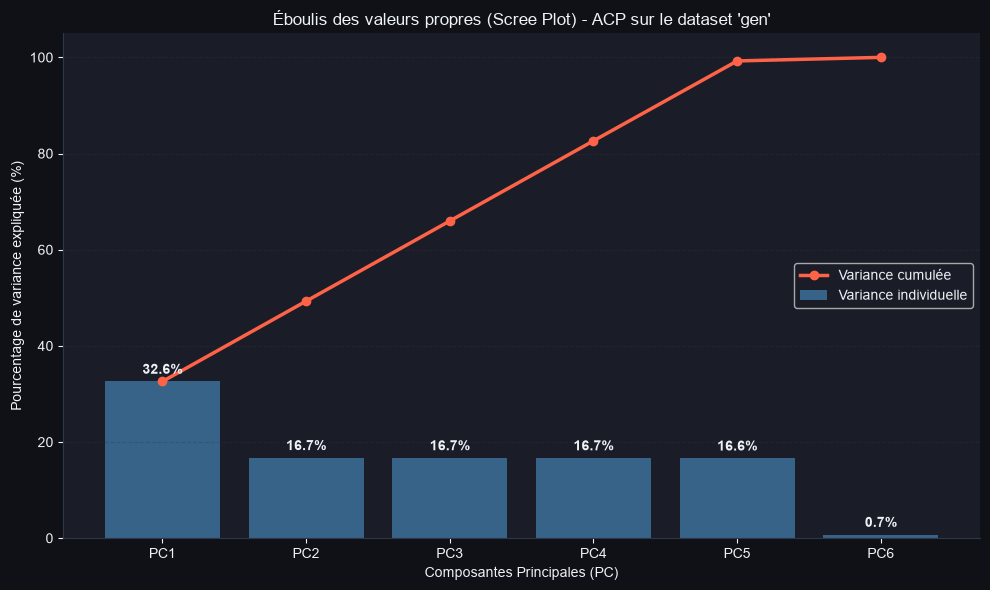

In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing, decomposition

# 1. Sélection des variables numériques
numerical_features = ["rain", "temp", "days", "fertilizer", "irrigation", "yield"]
X_pca = gen[numerical_features]

# 2. Standardisation des données (Crucial pour l'ACP)
scaler = preprocessing.StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

# On repasse en numpy array au cas où votre paramètre transform_output="pandas" soit encoreactif
X_scaled_arr = np.array(X_scaled)

# 3. Calcul de l'ACP
pca = decomposition.PCA()
pca.fit(X_scaled_arr)

# 4. Extraction de la variance expliquée par composante (en pourcentage)
explained_variance = pca.explained_variance_ratio_ * 100
cumulative_variance = np.cumsum(explained_variance)

# 5. Visualisation : Éboulis des valeurs propres
plt.figure(figsize=(10, 6))

# Histogramme pour la variance expliquée par chaque axe (PC)
bars = plt.bar(
    range(1, len(explained_variance) + 1),
    explained_variance,
    alpha=0.7,
    color="steelblue",
    label="Variance individuelle",
)

# Ligne de tendance pour la variance cumulée
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o",
    color="tomato",
    linewidth=2.5,
    label="Variance cumulée",
)

# Ajout des pourcentages au-dessus des barres pour une lecture facile
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 1,
        f"{yval:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

plt.title("Éboulis des valeurs propres (Scree Plot) - ACP sur le dataset 'gen'")
plt.xlabel("Composantes Principales (PC)")
plt.ylabel("Pourcentage de variance expliquée (%)")
plt.xticks(
    range(1, len(explained_variance) + 1),
    [f"PC{i}" for i in range(1, len(explained_variance) + 1)],
)
plt.ylim(0, 105)
plt.legend(loc="center right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

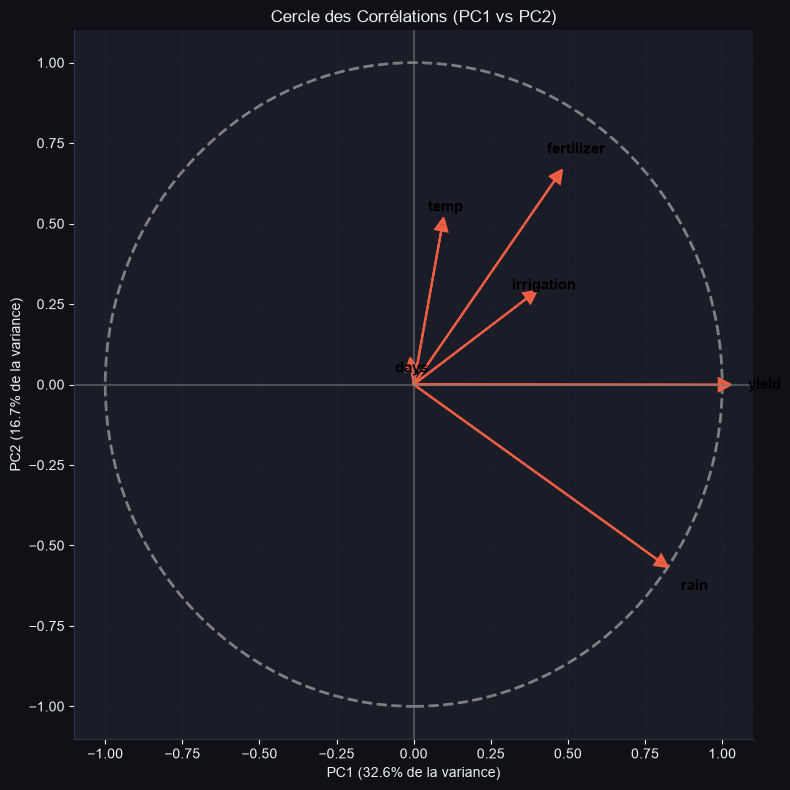

In [ ]:
# ==========================================
# CERCLE DES CORRÉLATIONS (PC1 vs PC2)
# ==========================================

coordonnees = pca.components_.T * np.sqrt(pca.explained_variance_)

plt.figure(figsize=(8, 8))
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)

circle = plt.Circle((0, 0), 1, color="gray", fill=False, linestyle="--", linewidth=2)
plt.gca().add_artist(circle)

plt.axhline(0, color="gray", linestyle="-", alpha=0.5)
plt.axvline(0, color="gray", linestyle="-", alpha=0.5)

for i, feature in enumerate(numerical_features):
    x = coordonnees[i, 0]
    y = coordonnees[i, 1]

    plt.arrow(
        0,
        0,
        x,
        y,
        head_width=0.04,
        head_length=0.04,
        color="tomato",
        alpha=0.9,
        linewidth=1.5,
    )

    # MODIFICATION : Texte en BLANC
    plt.text(
        x * 1.15,
        y * 1.15,
        feature,
        color="white",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
    )

# J'ai passé le titre et les axes en blanc également pour votre Dark Mode
plt.title("Cercle des Corrélations (PC1 vs PC2)", color="white")
plt.xlabel(f"PC1 ({explained_variance[0]:.1f}%)", color="white")
plt.ylabel(f"PC2 ({explained_variance[1]:.1f}%)", color="white")

# Optionnel : si les graduations (chiffres sur les axes) sont noires, on les passe en blanc
plt.tick_params(colors="white")

plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [147]:
# 1. Échantillonnage
sample_df = gen.sample(n=6000, random_state=42).copy()

sample_df["fertilizer_str"] = sample_df["fertilizer"].map({1: "Fert=1", 0: "Fert=0"})
sample_df["irrigation_str"] = sample_df["irrigation"].map({1: "Irrig=1", 0: "Irrig=0"})
sample_df["combination"] = (
    sample_df["fertilizer_str"] + " | " + sample_df["irrigation_str"]
)

combo_colors = {
    "Fert=0 | Irrig=0": "#e74c3c",  # Rouge
    "Fert=0 | Irrig=1": "#f39c12",  # Orange
    "Fert=1 | Irrig=0": "#3498db",  # Bleu
    "Fert=1 | Irrig=1": "#2ecc71",  # Vert
}

# Coefficients de l'équation
intercept = 40
coef_rain = 50
coef_temp = 200
coef_fert = 15000
coef_irrig = 12000

fig = go.Figure()

# Grille pour les plans 3D
x_range = np.linspace(sample_df["rain"].min(), sample_df["rain"].max(), 15)
y_range = np.linspace(sample_df["temp"].min(), sample_df["temp"].max(), 15)
x_grid, y_grid = np.meshgrid(x_range, y_range)

combos_list = [
    (0, 0, "Fert=0 | Irrig=0"),
    (0, 1, "Fert=0 | Irrig=1"),
    (1, 0, "Fert=1 | Irrig=0"),
    (1, 1, "Fert=1 | Irrig=1"),
]

for fert_val, irrig_val, label in combos_list:
    subset = sample_df[sample_df["combination"] == label]
    color = combo_colors[label]

    # 1. Nuage de points réels (3D)
    fig.add_trace(
        go.Scatter3d(
            x=subset["rain"],
            y=subset["temp"],
            z=subset["yield"],
            mode="markers",
            name=label,
            marker=dict(size=3, color=color, opacity=0.6),
        )
    )

    # 2. Plan 3D de régression pour cette combinaison
    z_grid = (
        intercept
        + coef_rain * x_grid
        + coef_temp * y_grid
        + coef_fert * fert_val
        + coef_irrig * irrig_val
    )
    fig.add_trace(
        go.Surface(
            x=x_grid,
            y=y_grid,
            z=z_grid,
            showscale=False,
            opacity=0.3,
            colorscale=[[0, color], [1, color]],
            name=f"Plan {label}",
            hoverinfo="skip",
        )
    )

# Mise en page Plotly corrigée (compatible toutes versions)
fig.update_layout(
    title=dict(
        text="Plotly 3D Interactif : Yield = f(Rain, Temp) par (Fertilizer, Irrigation)",
        font=dict(size=15, color="#edf2f7"),
    ),
    paper_bgcolor="#0f1117",
    plot_bgcolor="#1a1d27",
    scene=dict(
        xaxis=dict(
            title="Rainfall (mm)",
            color="#edf2f7",
            backgroundcolor="#1a1d27",
            gridcolor="#2d3748",
        ),
        yaxis=dict(
            title="Temperature (°C)",
            color="#edf2f7",
            backgroundcolor="#1a1d27",
            gridcolor="#2d3748",
        ),
        zaxis=dict(
            title="Yield (hg/ha)",
            color="#edf2f7",
            backgroundcolor="#1a1d27",
            gridcolor="#2d3748",
        ),
    ),
    legend=dict(font=dict(color="#edf2f7")),
    margin=dict(l=0, r=0, b=0, t=40),
)

fig.show()

Entraînement du modèle et calcul de l'importance des variables en cours...


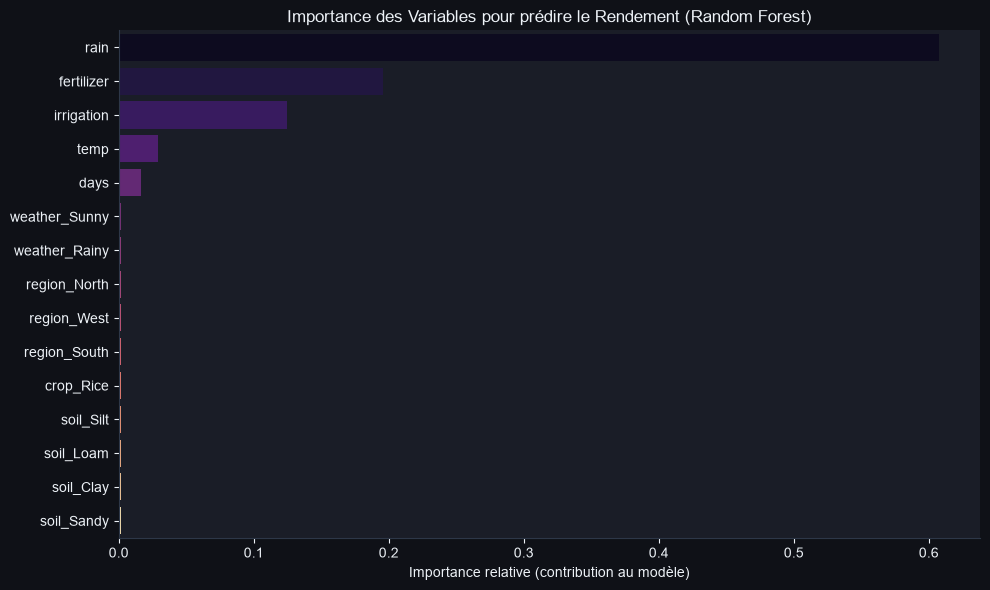

In [145]:
X = gen.drop(columns=[TARGET])
y = gen[TARGET]
X_encoded = pd.get_dummies(X, drop_first=True)
sample_idx = X_encoded.sample(min(5000000, len(X_encoded)), random_state=42).index

rf = ensemble.RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
print("Entraînement du modèle et calcul de l'importance des variables en cours...")
rf.fit(X_encoded.loc[sample_idx], y.loc[sample_idx])

# Extraction et tri de l'importance des variables
importances = pd.DataFrame(
    {"Variable": X_encoded.columns, "Importance": rf.feature_importances_}
).sort_values(by="Importance", ascending=False)

# Visualisation des 15 variables les plus importantes
plt.figure(figsize=(10, 6))
sns.barplot(data=importances.head(15), x="Importance", y="Variable", palette="magma")
plt.title("Importance des Variables pour prédire le Rendement (Random Forest)")
plt.xlabel("Importance relative (contribution au modèle)")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [139]:
import numpy as np
from sklearn import model_selection, ensemble, metrics

# 1. Sélection des variables numériques
# (fertilizer et irrigation sont déjà des 0/1 dans votre dataset gen)
numerical_features = ["rain", "temp", "days", "fertilizer", "irrigation"]
target = "yield"

# Préparation de X et y
X = gen[numerical_features]
y = gen[target]

# 2. Séparation Entraînement (80%) / Test (20%)
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Entraînement du modèle (Random Forest)
print(f"Entraînement sur {len(X_train):,} lignes en cours...")
rf_model = ensemble.RandomForestRegressor(
    n_estimators=50, max_depth=12, random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)

# 4. Prédictions sur le jeu de test
print("Évaluation sur le jeu de test...")
y_pred = rf_model.predict(X_test)

# 5. Calcul des scores
r2 = metrics.r2_score(y_test, y_pred)
rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
mae = metrics.mean_absolute_error(y_test, y_pred)

print("\n" + "=" * 50)
print("=== SCORES DU MODÈLE (Variables Numériques Seules) ===")
print("=" * 50)
print(
    f"R² (Précision globale) : {r2:.3f}  (1.0 = parfait, 0.0 = aussi bien que le hasard)"
)
print(f"RMSE (Erreur moyenne)  : {rmse:,.0f} hg/ha")
print(f"MAE (Erreur absolue)   : {mae:,.0f} hg/ha")

Entraînement sur 800,000 lignes en cours...
Évaluation sur le jeu de test...

=== SCORES DU MODÈLE (Variables Numériques Seules) ===
R² (Précision globale) : 0.913  (1.0 = parfait, 0.0 = aussi bien que le hasard)
RMSE (Erreur moyenne)  : 5,022 hg/ha
MAE (Erreur absolue)   : 4,007 hg/ha


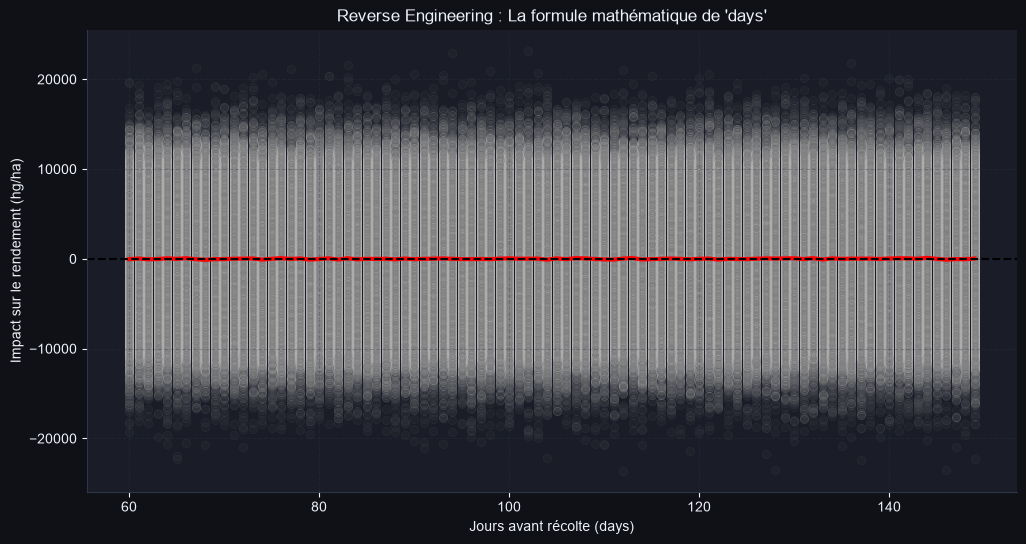

In [ ]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

# 1. On prend toutes les variables numériques SAUF 'days'
features_without_days = ["rain", "temp", "fertilizer", "irrigation"]

X_lin = gen[features_without_days]
y_real = gen["yield"]

# 2. On entraîne la Régression Linéaire (elle va capter les coefficients parfaits)
lr = LinearRegression()
lr.fit(X_lin, y_real)

# 3. On calcule le rendement théorique "sans tenir compte des jours"
y_pred = lr.predict(X_lin)

# 4. LE SECRET EST ICI : Le Résidu (l'erreur)
# C'est la différence entre la réalité et la prédiction linéaire.
# Ce qu'il reste ici, c'est littéralement la fonction f(days) + le bruit.
gen["residu_days"] = y_real - y_pred

# 5. On trace la formule de 'days'
plt.figure(figsize=(12, 6))

# Les points bruts (en gris clair pour ne pas saturer l'œil)
sns.scatterplot(x=gen["days"], y=gen["residu_days"], alpha=0.05, color="gray")

# La ligne rouge qui calcule la moyenne de l'erreur pour chaque jour
# C'est elle qui va vous donner la formule exacte !
sns.lineplot(
    x=gen["days"], y=gen["residu_days"], color="red", linewidth=3, errorbar=None
)

plt.title("Reverse Engineering : La formule mathématique de 'days'")
plt.xlabel("Jours avant récolte (days)")
plt.ylabel("Impact sur le rendement (hg/ha)")
plt.axhline(0, color="black", linestyle="--")  # Ligne zéro de référence
plt.grid(True, alpha=0.3)
plt.show()

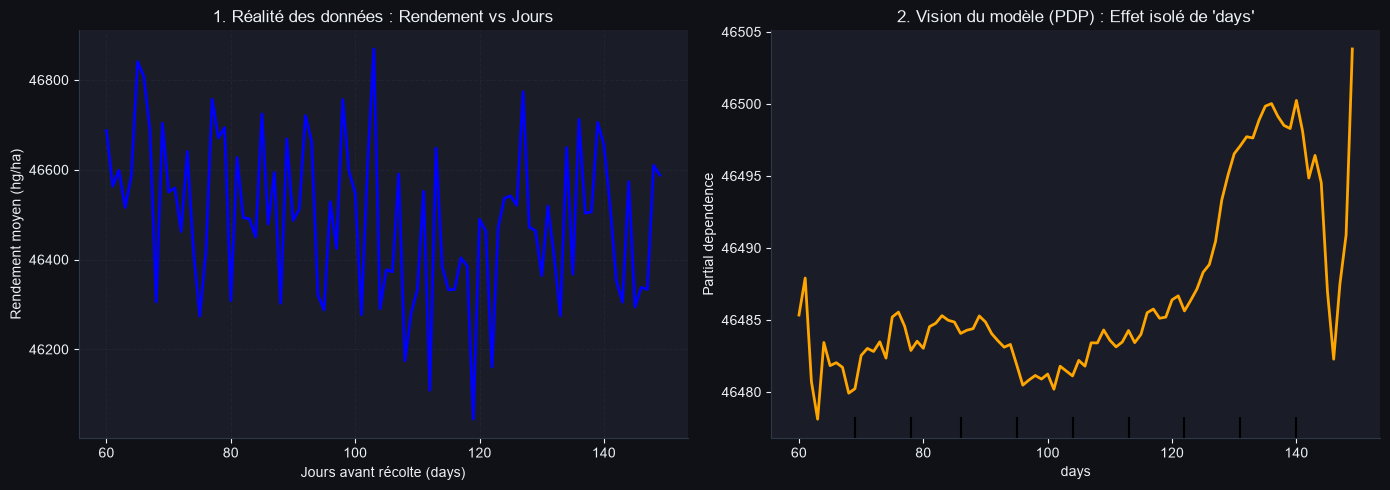

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import PartialDependenceDisplay

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ---------------------------------------------------------
# Méthode 1 : L'analyse visuelle directe des données
# ---------------------------------------------------------
# On calcule le rendement moyen pour chaque durée de récolte
days_trend = gen.groupby("days")["yield"].mean().reset_index()

sns.lineplot(data=days_trend, x="days", y="yield", ax=ax1, color="blue", linewidth=2)
ax1.set_title("1. Réalité des données : Rendement vs Jours")
ax1.set_xlabel("Jours avant récolte (days)")
ax1.set_ylabel("Rendement moyen (hg/ha)")
ax1.grid(True, alpha=0.3)

# ---------------------------------------------------------
# Méthode 2 : Ce que le Random Forest a appris (PDP)
# ---------------------------------------------------------
# Le "Partial Dependence Plot" isole l'effet strict d'une variable
X_train_float = X_train.astype(float)
PartialDependenceDisplay.from_estimator(
    rf_model,
    X_train_float,
    features=["days"],
    ax=ax2,
    line_kw={"color": "orange", "linewidth": 2},
)
ax2.set_title("2. Vision du modèle (PDP) : Effet isolé de 'days'")
ax2.set_xlabel("Jours avant récolte (days)")
ax2.set_ylabel("Impact sur la prédiction (hg/ha)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## FAO DATASET

### Skewed target Distribution

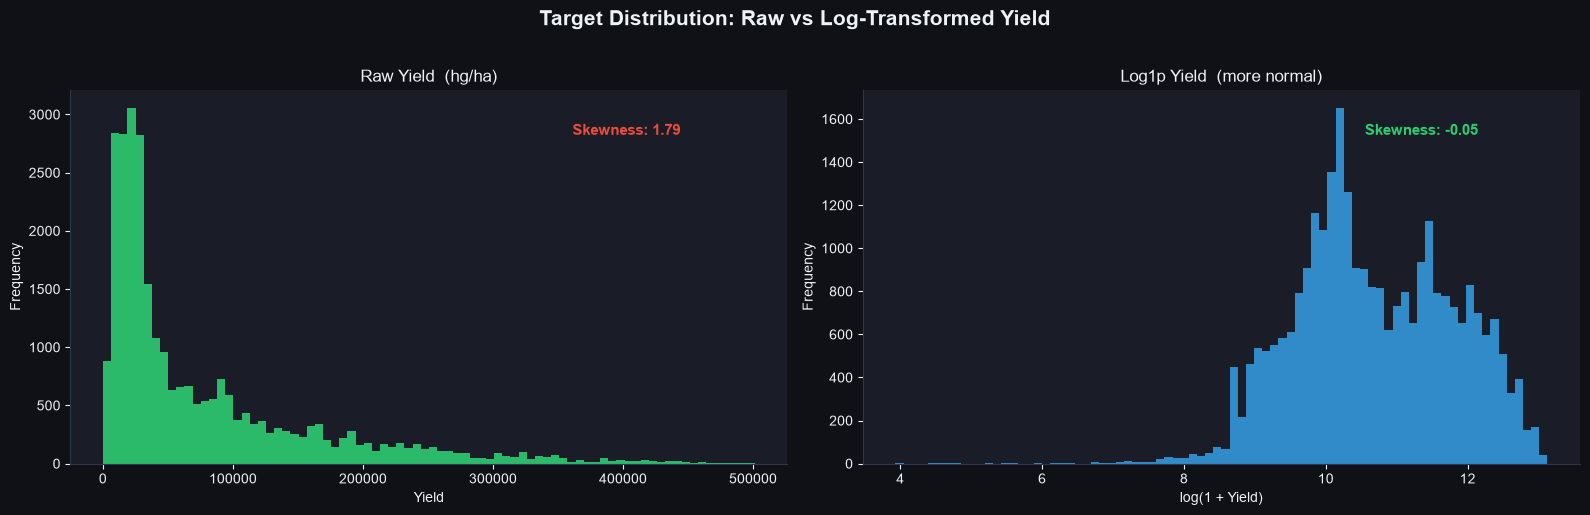


💡 Insight: Raw yield is heavily right-skewed (skew=1.79).
   Taking log1p brings it much closer to Normal — this will help linear models
   and reduce the influence of extreme outlier yields.


In [77]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(
    "Target Distribution: Raw vs Log-Transformed Yield",
    fontsize=15,
    fontweight="bold",
    y=1.02,
)

# Raw distribution
axes[0].hist(agri["yield"], bins=80, color=ACCENT, edgecolor="none", alpha=0.9)
axes[0].set_title("Raw Yield  (hg/ha)", fontsize=12)
axes[0].set_xlabel("Yield")
axes[0].set_ylabel("Frequency")
skew_raw = agri["yield"].skew()
axes[0].text(
    0.7,
    0.88,
    f"Skewness: {skew_raw:.2f}",
    transform=axes[0].transAxes,
    color="#e74c3c",
    fontsize=11,
    fontweight="bold",
)

# Log distribution
log_yield = np.log1p(agri["yield"])  # log transform.
axes[1].hist(log_yield, bins=80, color="#3498db", edgecolor="none", alpha=0.9)
axes[1].set_title("Log1p Yield  (more normal)", fontsize=12)
axes[1].set_xlabel("log(1 + Yield)")
axes[1].set_ylabel("Frequency")
skew_log = log_yield.skew()
axes[1].text(
    0.7,
    0.88,
    f"Skewness: {skew_log:.2f}",
    transform=axes[1].transAxes,
    color=ACCENT,
    fontsize=11,
    fontweight="bold",
)

plt.tight_layout()
plt.savefig(
    PLOTS / "fig_target_dist.png", dpi=150, bbox_inches="tight", facecolor=BG_COLOR
)
plt.show()

print(f"\n💡 Insight: Raw yield is heavily right-skewed (skew={skew_raw:.2f}).")
print("   Taking log1p brings it much closer to Normal — this will help linear models")
print("   and reduce the influence of extreme outlier yields.")


### Yield distribution by Crop

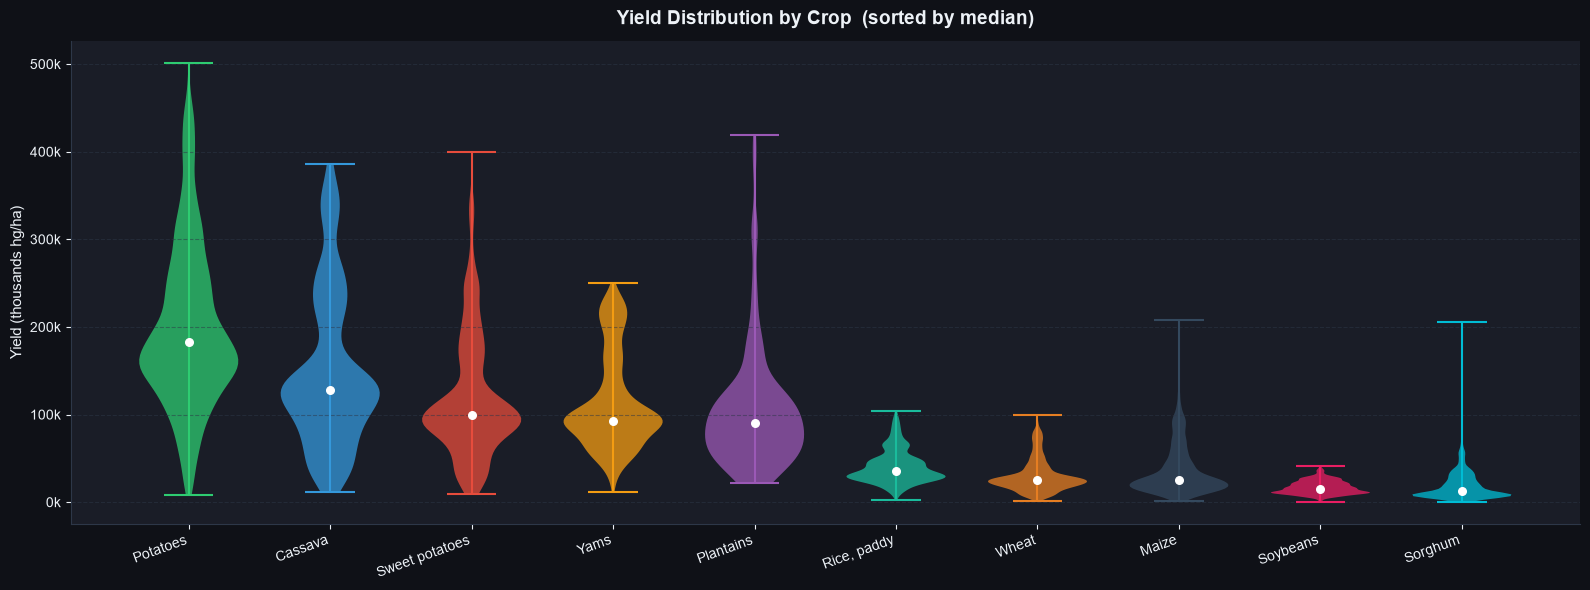

💡 Insight: Potatoes dominate in median yield, but also have HUGE variance.
   Sorghum & Soybeans are the lowest — and tight distributions (easier to predict).


In [78]:
crop_order = agri.groupby("crop")["yield"].median().sort_values(ascending=False).index
crop_colors = {crop: PALETTE[i] for i, crop in enumerate(crop_order)}

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor(BG_COLOR)

for i, crop in enumerate(crop_order):
    data = agri[agri["crop"] == crop]["yield"] / 1000  # Convert to thousands.
    parts = ax.violinplot(data, positions=[i], widths=0.7, showmedians=False)
    for pc in parts["bodies"]:
        pc.set_facecolor(crop_colors[crop])
        pc.set_alpha(0.75)
    parts["cbars"].set_color(crop_colors[crop])
    parts["cmins"].set_color(crop_colors[crop])
    parts["cmaxes"].set_color(crop_colors[crop])
    # Add median dot.
    ax.scatter([i], [data.median()], color="white", s=30, zorder=5)

ax.set_xticks(range(len(crop_order)))
ax.set_xticklabels(
    [c.replace(" and others", "") for c in crop_order],
    rotation=20,
    ha="right",
    fontsize=10,
)
ax.set_ylabel("Yield (thousands hg/ha)", fontsize=11)
ax.set_title(
    "Yield Distribution by Crop  (sorted by median)",
    fontsize=14,
    fontweight="bold",
    pad=12,
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}k"))
ax.grid(axis="y")

plt.tight_layout()
plt.savefig(
    PLOTS / "fig_crop_violin.png", dpi=150, bbox_inches="tight", facecolor=BG_COLOR
)
plt.show()

print("💡 Insight: Potatoes dominate in median yield, but also have HUGE variance.")
print(
    "   Sorghum & Soybeans are the lowest — and tight distributions (easier to predict)."
)


### Optimal Temperature by Crop


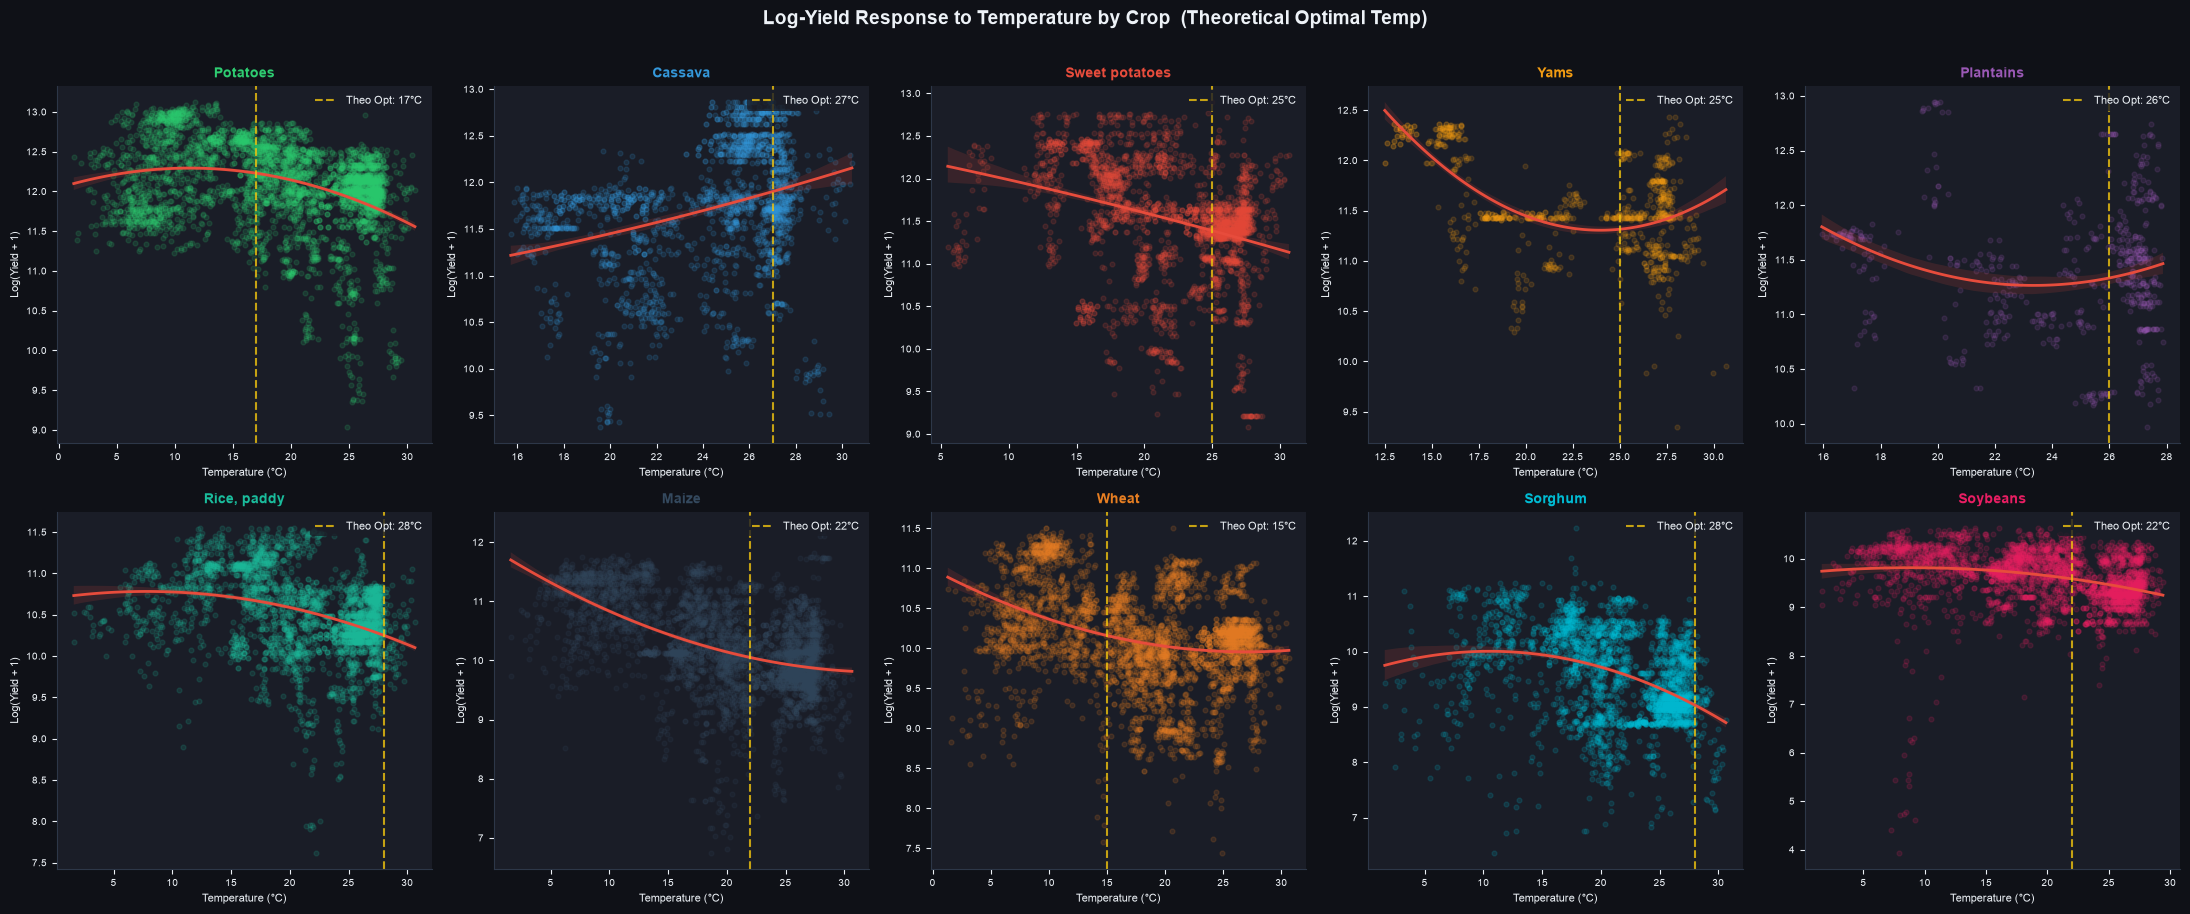

💡 Plot generated with Log-Yield!


In [ ]:
# Theoretical crop-specific optimum temperatures (°C)
CROP_OPT_TEMPS = {
    "Wheat": 15,
    "Rice, paddy": 28,
    "Maize": 22,
    "Potatoes": 17,
    "Soybeans": 22,
    "Sorghum": 28,
    "Cassava": 27,
    "Sweet potatoes": 25,
    "Plantains and others": 26,
    "Yams": 25,
}

# Create log-transformed yield for testing visualization
df_temp = agri.copy()
df_temp["log_yield"] = np.log1p(df_temp["yield"])

crop_order = df_temp.groupby("crop")["yield"].mean().sort_values(ascending=False).index

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()
fig.suptitle(
    "Log-Yield Response to Temperature by Crop  (Theoretical Optimal Temp)",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
fig.patch.set_facecolor(BG_COLOR)

for idx, crop in enumerate(crop_order):
    sub = df_temp[df_temp["crop"] == crop]
    ax = axes[idx]

    # Scatter plot & polynomial regression (degree 2) on log_yield
    sns.regplot(
        data=sub,
        x="temp",
        y="log_yield",
        order=2,
        ax=ax,
        scatter_kws={"alpha": 0.15, "s": 12, "color": crop_colors[crop]},
        line_kws={"color": "#e74c3c", "linewidth": 2},
    )

    # Theoretical optimal temperature line
    opt_temp = CROP_OPT_TEMPS.get(crop, 22)
    ax.axvline(
        x=opt_temp,
        color="#f1c40f",
        linestyle="--",
        alpha=0.8,
        label=f"Theo Opt: {opt_temp}°C",
    )
    ax.legend(loc="upper right", fontsize=8, facecolor=CARD_COLOR, edgecolor="none")

    ax.set_title(
        crop.replace(" and others", ""),
        fontsize=10,
        color=crop_colors[crop],
        fontweight="bold",
    )
    ax.set_xlabel("Temperature (°C)", fontsize=8)
    ax.set_ylabel("Log(Yield + 1)", fontsize=8)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(
    PLOTS / "fig_optimal_temp_per_crop_log.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR,
)
plt.show()

print("💡 Plot generated with Log-Yield!")


### Temporal Trends

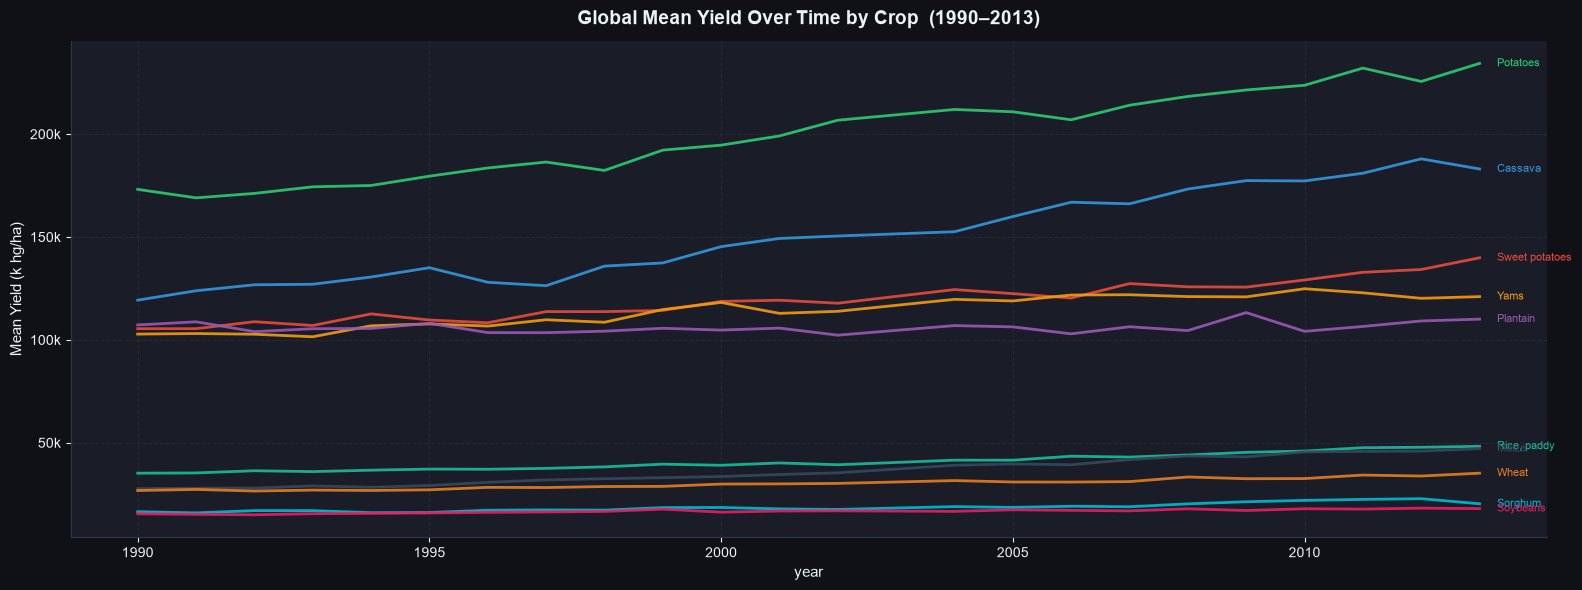

📈 Yield Growth Rate (1990 → 2013):
   Potatoes                  +  35.4%  ███
   Cassava                   +  53.4%  █████
   Sweet potatoes            +  32.7%  ███
   Yams                      +  17.7%  █
   Plantains and others      +   2.6%  
   Rice, paddy               +  37.1%  ███
   Maize                     +  70.2%  ███████
   Wheat                     +  31.5%  ███
   Sorghum                   +  23.4%  ██
   Soybeans                  +  16.3%  █


In [ ]:
yearly = agri.groupby(["year", "crop"])["yield"].mean().reset_index()

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor(BG_COLOR)

for i, crop in enumerate(crop_order):
    sub = yearly[yearly["crop"] == crop]
    ax.plot(
        sub["year"],
        sub["yield"] / 1000,
        color=crop_colors[crop],
        linewidth=2,
        label=crop.replace(" and others", ""),
        alpha=0.9,
    )
    # End-of-line label
    last = sub.iloc[-1]
    ax.text(
        last["year"] + 0.3,
        last["yield"] / 1000,
        crop.replace(" and others", "").replace("Plantains", "Plantain"),
        color=crop_colors[crop],
        fontsize=8,
        va="center",
    )

ax.set_xlabel("year", fontsize=11)
ax.set_ylabel("Mean Yield (k hg/ha)", fontsize=11)
ax.set_title(
    "Global Mean Yield Over Time by Crop  (1990–2013)",
    fontsize=14,
    fontweight="bold",
    pad=12,
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}k"))
ax.grid(True)

plt.tight_layout()
plt.savefig(
    PLOTS / "fig_yield_trend.png", dpi=150, bbox_inches="tight", facecolor=BG_COLOR
)
plt.show()

# Calculate growth rates
print("📈 Yield Growth Rate (1990 → 2013):")
for crop in crop_order:
    sub = yearly[yearly["crop"] == crop].set_index("year")
    start = sub["yield"].iloc[0]
    end = sub["yield"].iloc[-1]
    pct = ((end - start) / start) * 100
    bar = "█" * int(abs(pct) // 10)
    sign = "+" if pct > 0 else ""
    print(f"   {crop:<25} {sign}{pct:6.1f}%  {bar}")


### Correlation Heatmap

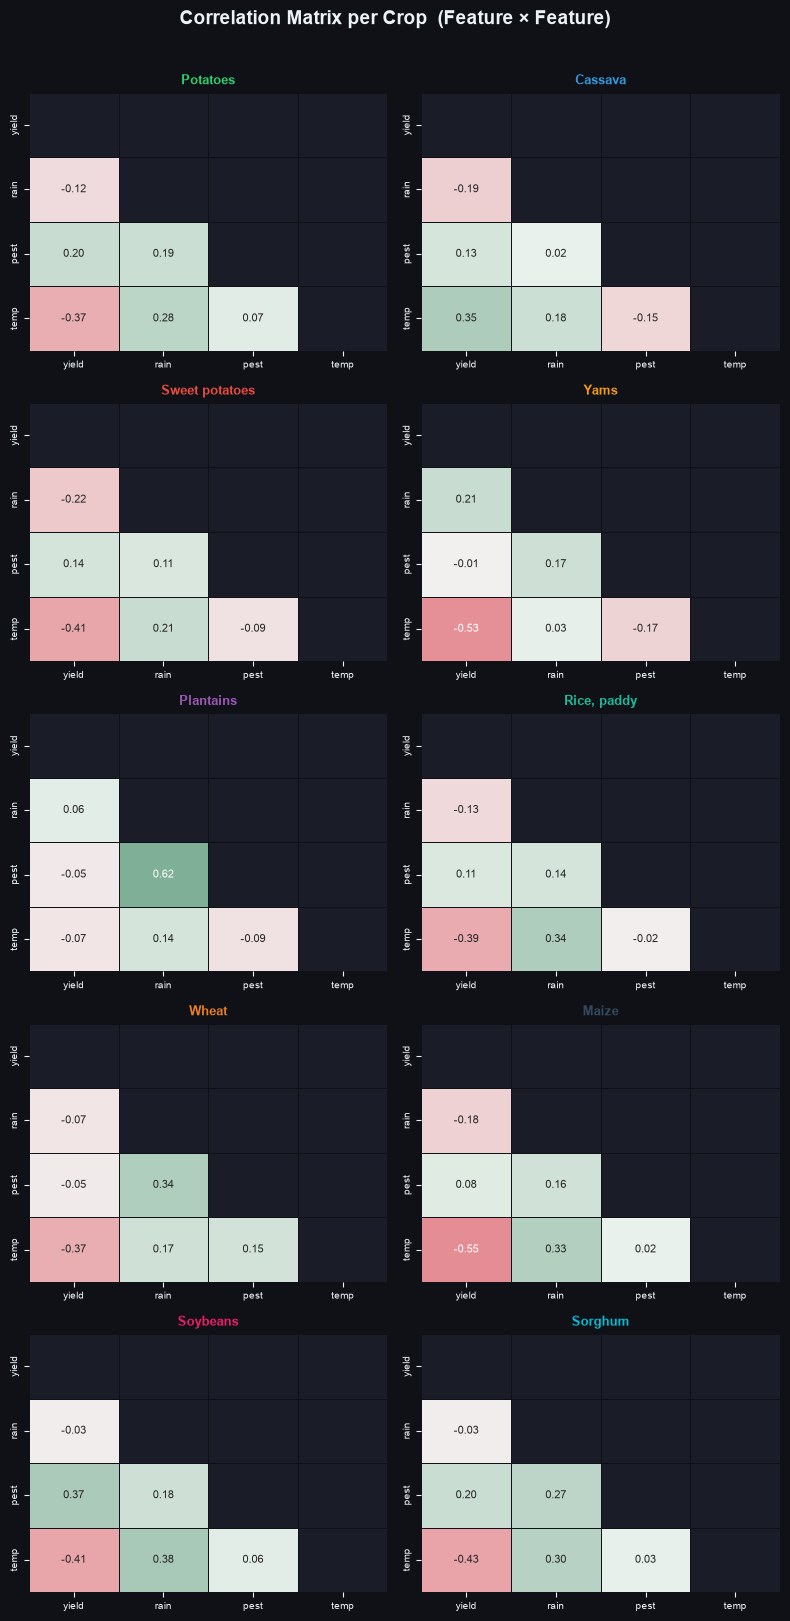

💡 Key Finding: Temperature is POSITIVELY correlated with yield for Cassava,
   but NEGATIVELY for other crops. One-size-fits-all climate models will fail!


In [83]:
features = [
    "yield",
    "rain",
    "pest",
    "temp",
]

fig, axes = plt.subplots(5, 2, figsize=(8, 16))
axes = axes.flatten()
fig.suptitle(
    "Correlation Matrix per Crop  (Feature × Feature)",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
fig.patch.set_facecolor(BG_COLOR)

for idx, crop in enumerate(crop_order):
    sub = agri[agri["crop"] == crop][features]
    corr = sub.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    cmap = sns.diverging_palette(10, 145, as_cmap=True)
    sns.heatmap(
        corr,
        ax=axes[idx],
        mask=mask,
        cmap=cmap,
        vmin=-1,
        vmax=1,
        annot=True,
        fmt=".2f",
        linewidths=0.5,
        linecolor="#0f1117",
        cbar=False,
        annot_kws={"size": 8},
    )
    axes[idx].set_title(
        crop.replace(" and others", ""),
        fontsize=9,
        color=crop_colors[crop],
        fontweight="bold",
    )
    axes[idx].tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(
    PLOTS / "fig_corr_per_crop.png", dpi=150, bbox_inches="tight", facecolor=BG_COLOR
)
plt.show()

print("💡 Key Finding: Temperature is POSITIVELY correlated with yield for Cassava,")
print("   but NEGATIVELY for other crops. One-size-fits-all climate models will fail!")


### Pesticide regressions

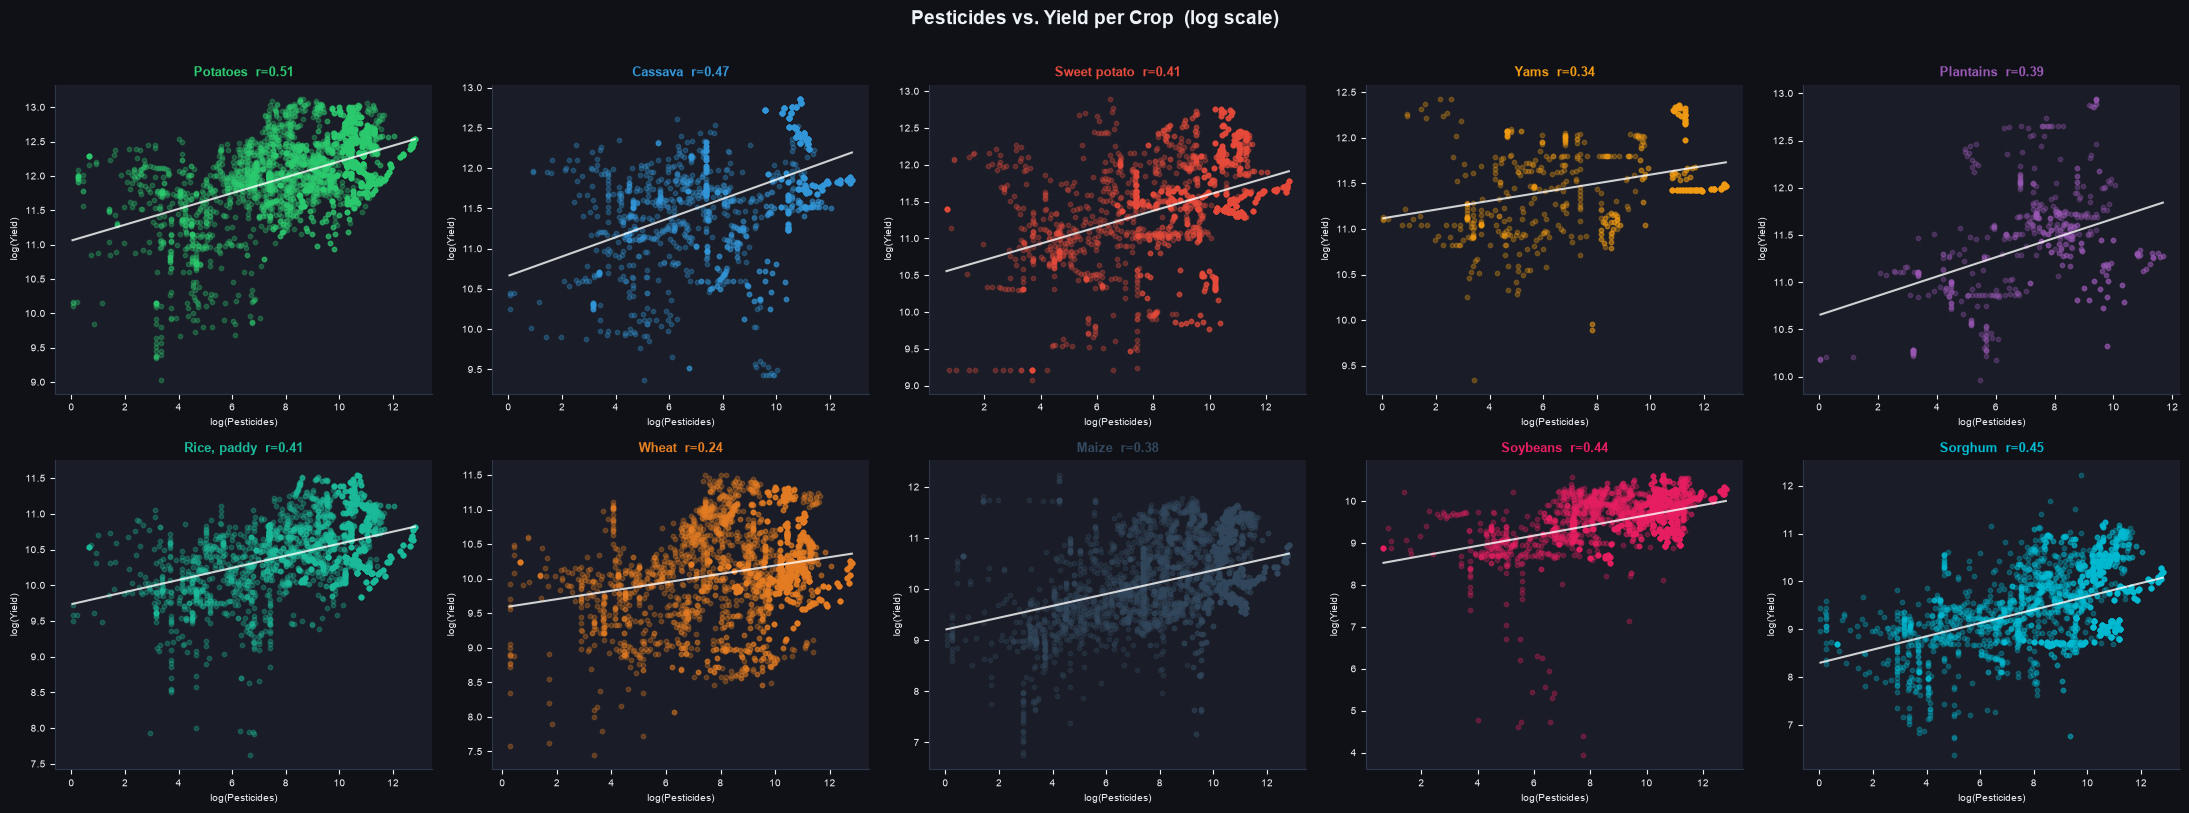

💡 Insight: The pesticide-yield relationship varies wildly.
   After log-transformation, a cleaner linear signal emerges for most crops.
   This is a classic confound: wealthy countries use more pesticides AND have better yields.


In [119]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()
fig.suptitle(
    "Pesticides vs. Yield per Crop  (log scale)", fontsize=14, fontweight="bold", y=1.01
)
fig.patch.set_facecolor(BG_COLOR)

for idx, crop in enumerate(crop_order):
    sub = agri[agri["crop"] == crop].copy()
    sub = sub[sub["pest"] > 0]
    color = crop_colors[crop]

    axes[idx].scatter(
        np.log1p(sub["pest"]),
        np.log1p(sub["yield"]),
        alpha=0.3,
        s=10,
        color=color,
    )

    # Trend line
    x = np.log1p(sub["pest"])
    y = np.log1p(sub["yield"])
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    x_line = np.linspace(x.min(), x.max(), 100)
    axes[idx].plot(x_line, p(x_line), color="white", linewidth=1.5, alpha=0.8)

    r = np.corrcoef(x, y)[0, 1]
    axes[idx].set_title(
        f"{crop.replace(' and others', '')[:12]}  r={r:.2f}",
        fontsize=9,
        color=color,
        fontweight="bold",
    )
    axes[idx].set_xlabel("log(Pesticides)", fontsize=7)
    axes[idx].set_ylabel("log(Yield)", fontsize=7)
    axes[idx].tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(
    PLOTS / "fig_pesticide_scatter.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR,
)
plt.show()

print("💡 Insight: The pesticide-yield relationship varies wildly.")
print("   After log-transformation, a cleaner linear signal emerges for most crops.")
print(
    "   This is a classic confound: wealthy countries use more pesticides AND have better yields."
)


### Geographic Heatmap

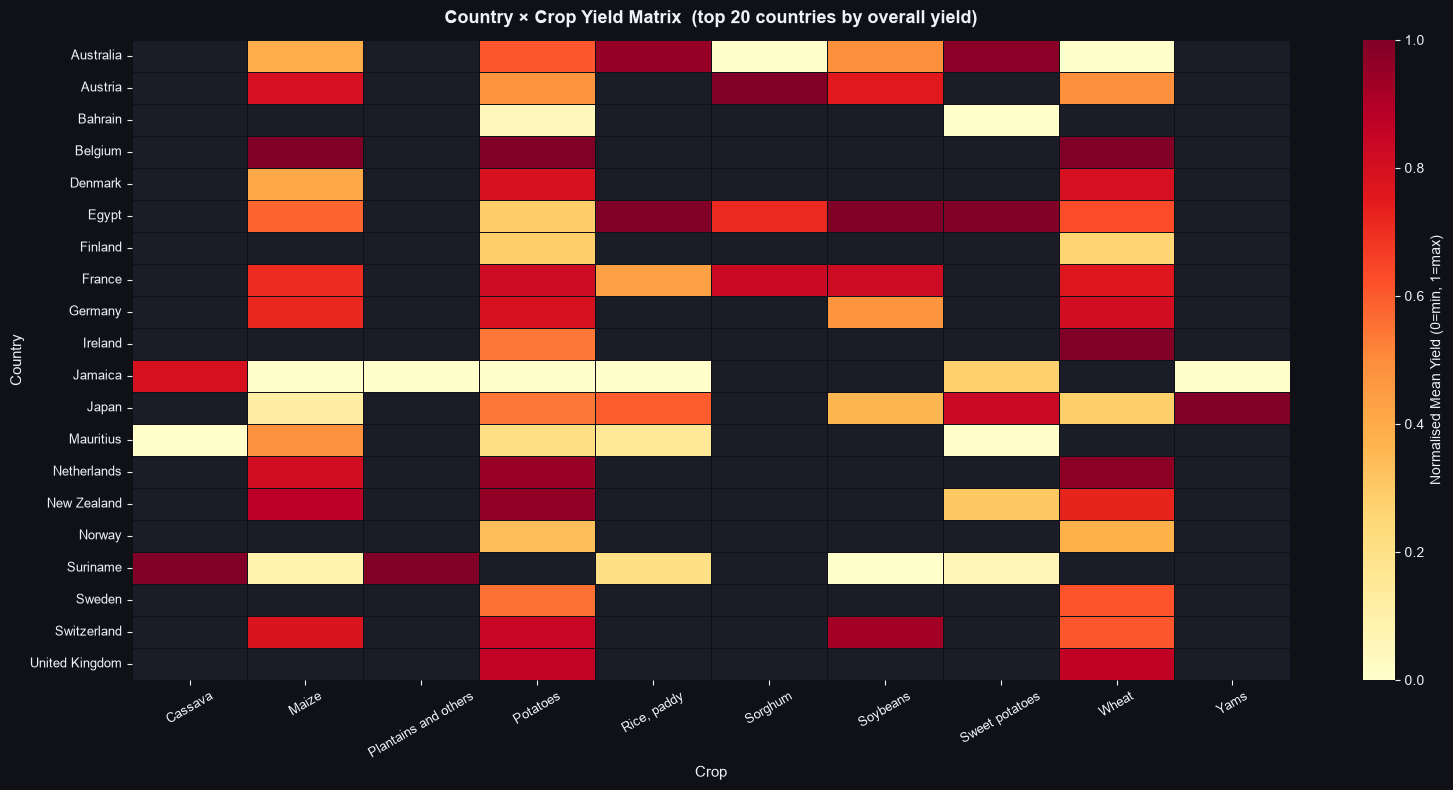

💡 Pattern: Northern Europe dominates potatoes & wheat.
   Tropical nations shine in cassava, yams & plantains.
   This geographic signal will be captured by country encoding.


In [ ]:
top_countries = (
    agri.groupby("country")["yield"].mean().sort_values(ascending=False).head(20).index
)
pivot = agri[agri["country"].isin(top_countries)].pivot_table(
    index="country", columns="crop", values="yield", aggfunc="mean"
)
# Normalise per column to see relative performance
pivot_norm = (pivot - pivot.min()) / (pivot.max() - pivot.min())

fig, ax = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor(BG_COLOR)

cmap = sns.color_palette("YlOrRd", as_cmap=True)
sns.heatmap(
    pivot_norm,
    ax=ax,
    cmap=cmap,
    annot=False,
    linewidths=0.5,
    linecolor="#0f1117",
    cbar_kws={"label": "Normalised Mean Yield (0=min, 1=max)"},
)

ax.set_title(
    "Country × Crop Yield Matrix  (top 20 countries by overall yield)",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
ax.set_xlabel("Crop", fontsize=11)
ax.set_ylabel("Country", fontsize=11)
ax.tick_params(axis="x", rotation=30, labelsize=9)
ax.tick_params(axis="y", labelsize=9)

plt.tight_layout()
plt.savefig(
    PLOTS / "fig_country_crop_heatmap.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR,
)
plt.show()

print("💡 Pattern: Northern Europe dominates potatoes & wheat.")
print("   Tropical nations shine in cassava, yams & plantains.")
print("   This geographic signal will be captured by country encoding.")


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Ordre et couleurs uniques par culture (cohérents avec la PALETTE de votre notebook)
crop_order = sorted(agri["crop"].unique())
crop_colors = {crop: PALETTE[i % len(PALETTE)] for i, crop in enumerate(crop_order)}

# 2. Création d'une grille 2x5 de cartes géo
fig = make_subplots(
    rows=2,
    cols=5,
    subplot_titles=[c.replace(" and others", "")[:15] for c in crop_order],
    specs=[[{"type": "geo"}] * 5] * 2,
    horizontal_spacing=0.01,
    vertical_spacing=0.08,
)

# 3. Traitement de chaque culture
for idx, crop in enumerate(crop_order):
    row = (idx // 5) + 1
    col = (idx % 5) + 1
    color = crop_colors[crop]

    # Pays producteurs de la culture
    sub_df = agri[agri["crop"] == crop]["country"].unique()
    producer_df = pd.DataFrame({"country": sub_df, "Produces": 1})

    # Trace Choropleth avec couleur fixe de la culture
    fig.add_trace(
        go.Choropleth(
            locations=producer_df["country"],
            locationmode="country names",
            z=producer_df["Produces"],
            colorscale=[[0, color], [1, color]],
            showscale=False,
            name=crop,
            hovertemplate=f"<b>%{{location}}</b><br>Produces: {crop}<extra></extra>",
        ),
        row=row,
        col=col,
    )

    # Configuration du style sombre pour la mini-carte
    geo_key = f"geo{idx + 1}" if idx > 0 else "geo"
    fig.layout[geo_key].update(
        bgcolor="#0f1117",
        showframe=False,
        showcoastlines=True,
        coastlinecolor="#2d3748",
        showland=True,
        landcolor="#1a1d27",  # Pays non-producteurs non coloriés (fond sombre)
        showocean=True,
        oceancolor="#0f1117",
        projection_scale=0.85,
    )

# 4. Thème global et titre
fig.update_layout(
    title=dict(
        text="<b>🌍 Global Producing Countries by Crop (Presence Map)</b>",
        font=dict(size=16, color="#edf2f7"),
        x=0.5,
    ),
    paper_bgcolor="#0f1117",
    font=dict(color="#edf2f7", size=10),
    height=550,
    margin=dict(l=10, r=10, t=60, b=10),
)

# Style des sous-titres de culture (avec la couleur de la culture)
for i, annotation in enumerate(fig.layout.annotations):
    crop_name = crop_order[i]
    annotation.font.color = crop_colors[crop_name]
    annotation.font.size = 11
    annotation.font.weight = "bold"

fig.show()

print("💡 Insight: Geographical specializations are striking across crops!")
print(
    "   Cassava & Yams are strictly tropical/equatorial, whereas Wheat & Potatoes span temperate regions globally."
)


💡 Insight: Geographical specializations are striking across crops!
   Cassava & Yams are strictly tropical/equatorial, whereas Wheat & Potatoes span temperate regions globally.


## FEATURE ENGINEERING

In [ ]:
data = agri.copy()

# Log-transform pesticides (reduces right-skew confound)
data["log_pesticides"] = np.log1p(data["pest"])

# Log-transform rainfall
data["log_rainfall"] = np.log1p(data["rain"])

# Rain × Temperature interaction
#    High rain + high temp = tropics (cassava, yams).
#    High rain + low temp = temperate agriculture (wheat, potatoes).
data["rain_temp_interaction"] = data["rain"] * data["temp"]

# Temperature deviation from crop-specific optimum
#    Each crop has a sweet-spot temperature. Deviation penalises extremes.
CROP_OPT_TEMPS = {
    "Wheat": 15,
    "Rice, paddy": 28,
    "Maize": 22,
    "Potatoes": 17,
    "Soybeans": 22,
    "Sorghum": 28,
    "Cassava": 27,
    "Sweet potatoes": 25,
    "Plantains and others": 26,
    "Yams": 25,
}
data["temp_deviation"] = data.apply(
    lambda r: abs(r["temp"] - CROP_OPT_TEMPS.get(r["crop"], 22)), axis=1
)

# Country-level mean yield (target encoding, careful of leakage!)
# We compute this on the full dataset for EDA but will compute CV-safe versions during modelling.
country_mean = data.groupby("country")["yield"].mean()
data["country_mean_yield"] = data["country"].map(country_mean)

# Crop-level mean yield
crop_mean = data.groupby("crop")["yield"].mean()
data["crop_mean_yield"] = data["crop"].map(crop_mean)

# Year normalised (model-friendly)
data["year_norm"] = (data["year"] - data["year"].min()) / (
    data["year"].max() - data["year"].min()
)

# Rainfall efficiency = yield per mm of rain
data["rain_efficiency"] = data["rain"] / (data["temp"] + 1)

#  Label Encode categoricals
le_area = preprocessing.LabelEncoder()
le_item = preprocessing.LabelEncoder()
data["area_enc"] = le_area.fit_transform(data["country"])
data["item_enc"] = le_item.fit_transform(data["crop"])

print("✅ Feature Engineering Complete!")
print("   Original features : 4")
print(f"   Engineered features: {data.shape[1] - agri.shape[1]}")
print(f"   Total features now : {data.shape[1]}")
print("\n📋 New features created:")
new_feats = [c for c in data.columns if c not in agri.columns]
for f in new_feats:
    print(f"   • {f}")


✅ Feature Engineering Complete!
   Original features : 4
   Engineered features: 10
   Total features now : 17

📋 New features created:
   • log_pesticides
   • log_rainfall
   • rain_temp_interaction
   • temp_deviation
   • country_mean_yield
   • crop_mean_yield
   • year_norm
   • rain_efficiency
   • area_enc
   • item_enc


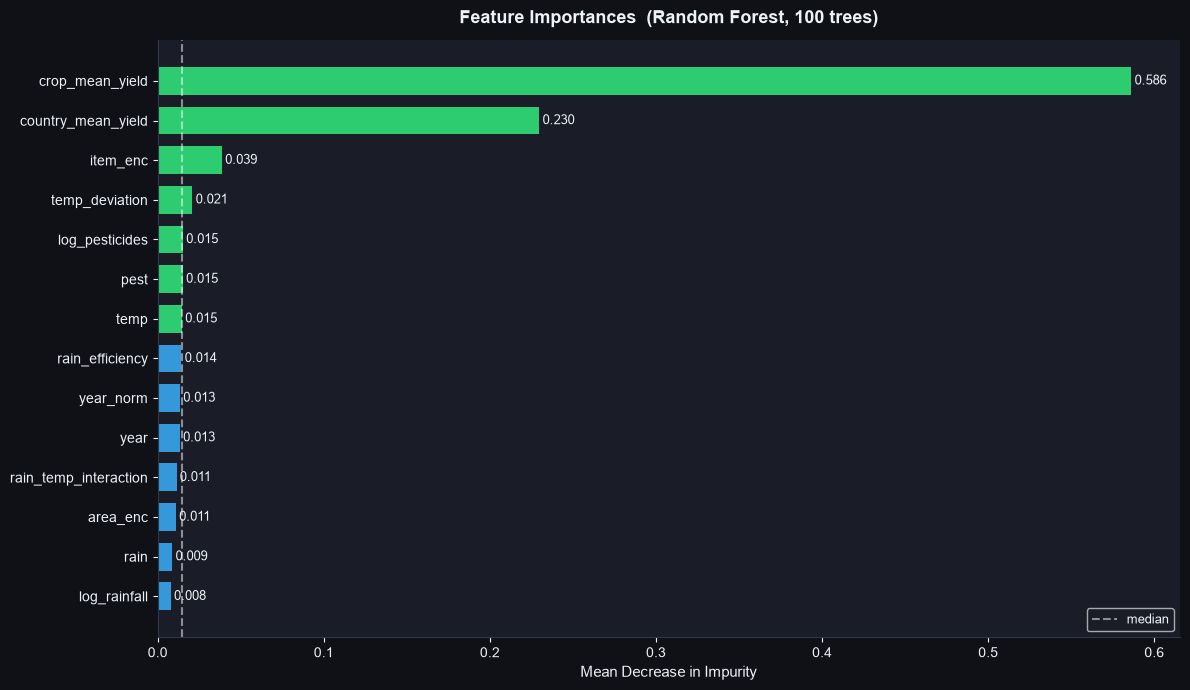

💡 Key Insight: Engineered features (country_mean_yield, crop_mean_yield) dominate!
   Year also scores high → technology/policy trends are real predictors.


In [ ]:
# Visualise feature importances from a quick RF (before formal tuning)
FEATURES = [
    "area_enc",
    "item_enc",
    "year",
    "year_norm",
    "rain",
    "log_rainfall",
    "pest",
    "log_pesticides",
    "temp",
    "temp_deviation",
    "rain_temp_interaction",
    "rain_efficiency",
    "country_mean_yield",
    "crop_mean_yield",
]

X = data[FEATURES]
y = data[TARGET]

quick_rf = ensemble.RandomForestRegressor(
    n_estimators=100, random_state=RANDOM, n_jobs=-1
)
quick_rf.fit(X, y)

importances = pd.Series(quick_rf.feature_importances_, index=FEATURES).sort_values(
    ascending=True
)

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(BG_COLOR)

colors = [ACCENT if v > importances.median() else "#3498db" for v in importances.values]
bars = ax.barh(
    importances.index, importances.values, color=colors, edgecolor="none", height=0.7
)

for bar, val in zip(bars, importances.values):
    ax.text(
        val + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
        fontsize=9,
    )

ax.axvline(
    importances.median(), color="white", linestyle="--", alpha=0.5, label="median"
)
ax.set_title(
    "Feature Importances  (Random Forest, 100 trees)",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
ax.set_xlabel("Mean Decrease in Impurity", fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(
    PLOTS / "fig_feature_importance.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR,
)
plt.show()

print(
    "💡 Key Insight: Engineered features (country_mean_yield, crop_mean_yield) dominate!"
)
print("   Year also scores high → technology/policy trends are real predictors.")


## CLUSTERING

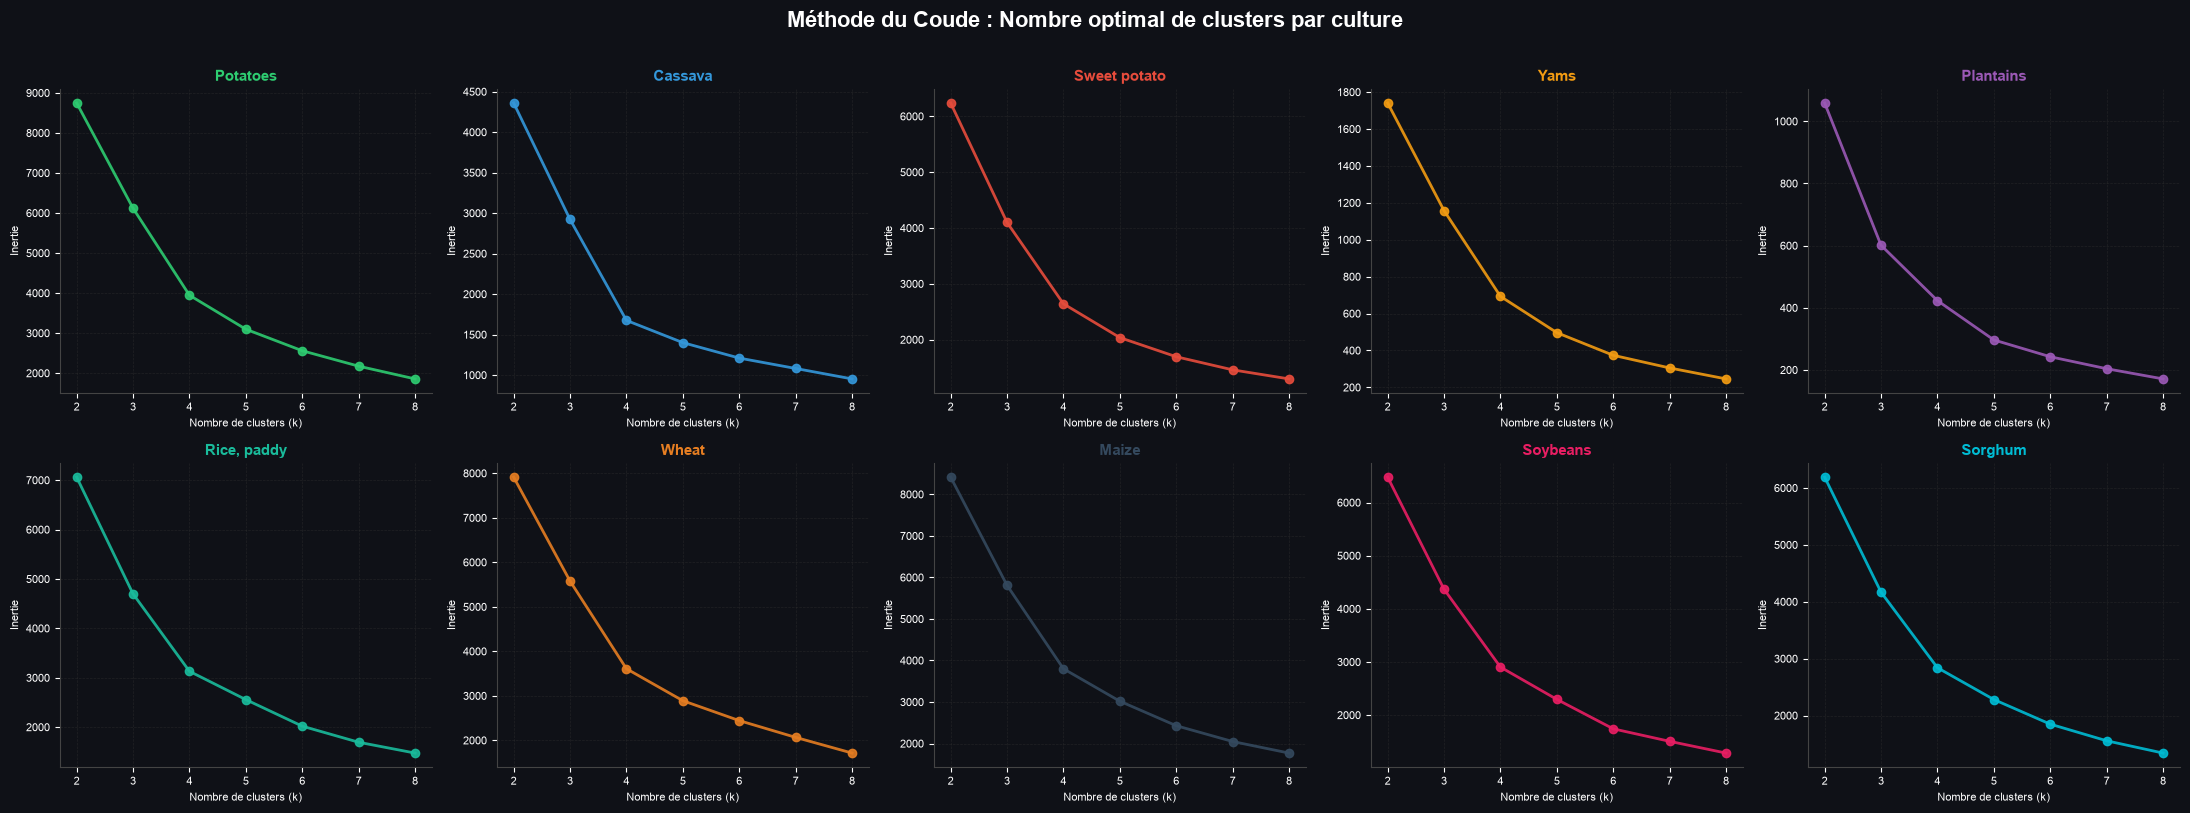

💡 Insight: Regardez où la courbe de chaque culture forme un 'coude' net.
   Certaines cultures (très localisées) n'auront besoin que de 2 clusters,
   tandis que d'autres (cultivées partout dans le monde) en nécessiteront 3 ou 4.


In [120]:
import matplotlib.pyplot as plt
from sklearn import cluster, preprocessing

# Assurez-vous que BG_COLOR, PALETTE et PLOTS sont déjà définis dans votre environnement
# Exemple si besoin :
# BG_COLOR = "#1e1e1e"
# PALETTE = px.colors.qualitative.Plotly * 2  # (pour avoir au moins 10 couleurs)

# 1. Définition de l'ordre et des couleurs (comme dans votre code)
crop_order = agri.groupby("crop")["yield"].median().sort_values(ascending=False).index
crop_colors = {crop: PALETTE[i] for i, crop in enumerate(crop_order)}

# Variables pour le clustering
features_to_cluster = ["temp", "rain", "pest"]
K_range = range(2, 9)  # On teste de 2 à 8 clusters

# 2. Préparation de la figure
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()
fig.suptitle(
    "Méthode du Coude : Nombre optimal de clusters par culture",
    fontsize=16,
    fontweight="bold",
    y=1.01,
    color="white",
)
fig.patch.set_facecolor(BG_COLOR)

# 3. Boucle sur chaque culture
for idx, crop in enumerate(crop_order):
    # Isolation et standardisation des données de la culture
    sub = agri[agri["crop"] == crop][features_to_cluster].copy()

    scaler = preprocessing.StandardScaler()
    X_scaled = scaler.fit_transform(sub)

    # Calcul de l'inertie pour chaque k
    inertias = []
    for k in K_range:
        kmeans = cluster.KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_scaled)
        inertias.append(kmeans.inertia_)

    # Récupération de la couleur
    color = crop_colors[crop]

    # Tracé de la courbe
    axes[idx].plot(
        K_range, inertias, marker="o", color=color, linewidth=2, markersize=6, alpha=0.9
    )

    # Stylisation du sous-graphique
    crop_title = crop.replace(" and others", "")[:12]
    axes[idx].set_title(f"{crop_title}", fontsize=11, color=color, fontweight="bold")
    axes[idx].set_xlabel("Nombre de clusters (k)", fontsize=8, color="white")
    axes[idx].set_ylabel("Inertie", fontsize=8, color="white")

    # Style de l'axe pour coller au fond sombre
    axes[idx].set_facecolor(BG_COLOR)
    axes[idx].tick_params(colors="white", labelsize=8)
    for spine in axes[idx].spines.values():
        spine.set_color("#444444")
    axes[idx].grid(color="#333333", linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()

# Sauvegarde de la figure (assurez-vous que la variable PLOTS existe, ex: Path("plots"))
# plt.savefig(
#     PLOTS / "fig_kmeans_elbow.png",
#     dpi=150,
#     bbox_inches="tight",
#     facecolor=BG_COLOR,
# )

plt.show()

print("💡 Insight: Regardez où la courbe de chaque culture forme un 'coude' net.")
print("   Certaines cultures (très localisées) n'auront besoin que de 2 clusters,")
print(
    "   tandis que d'autres (cultivées partout dans le monde) en nécessiteront 3 ou 4."
)

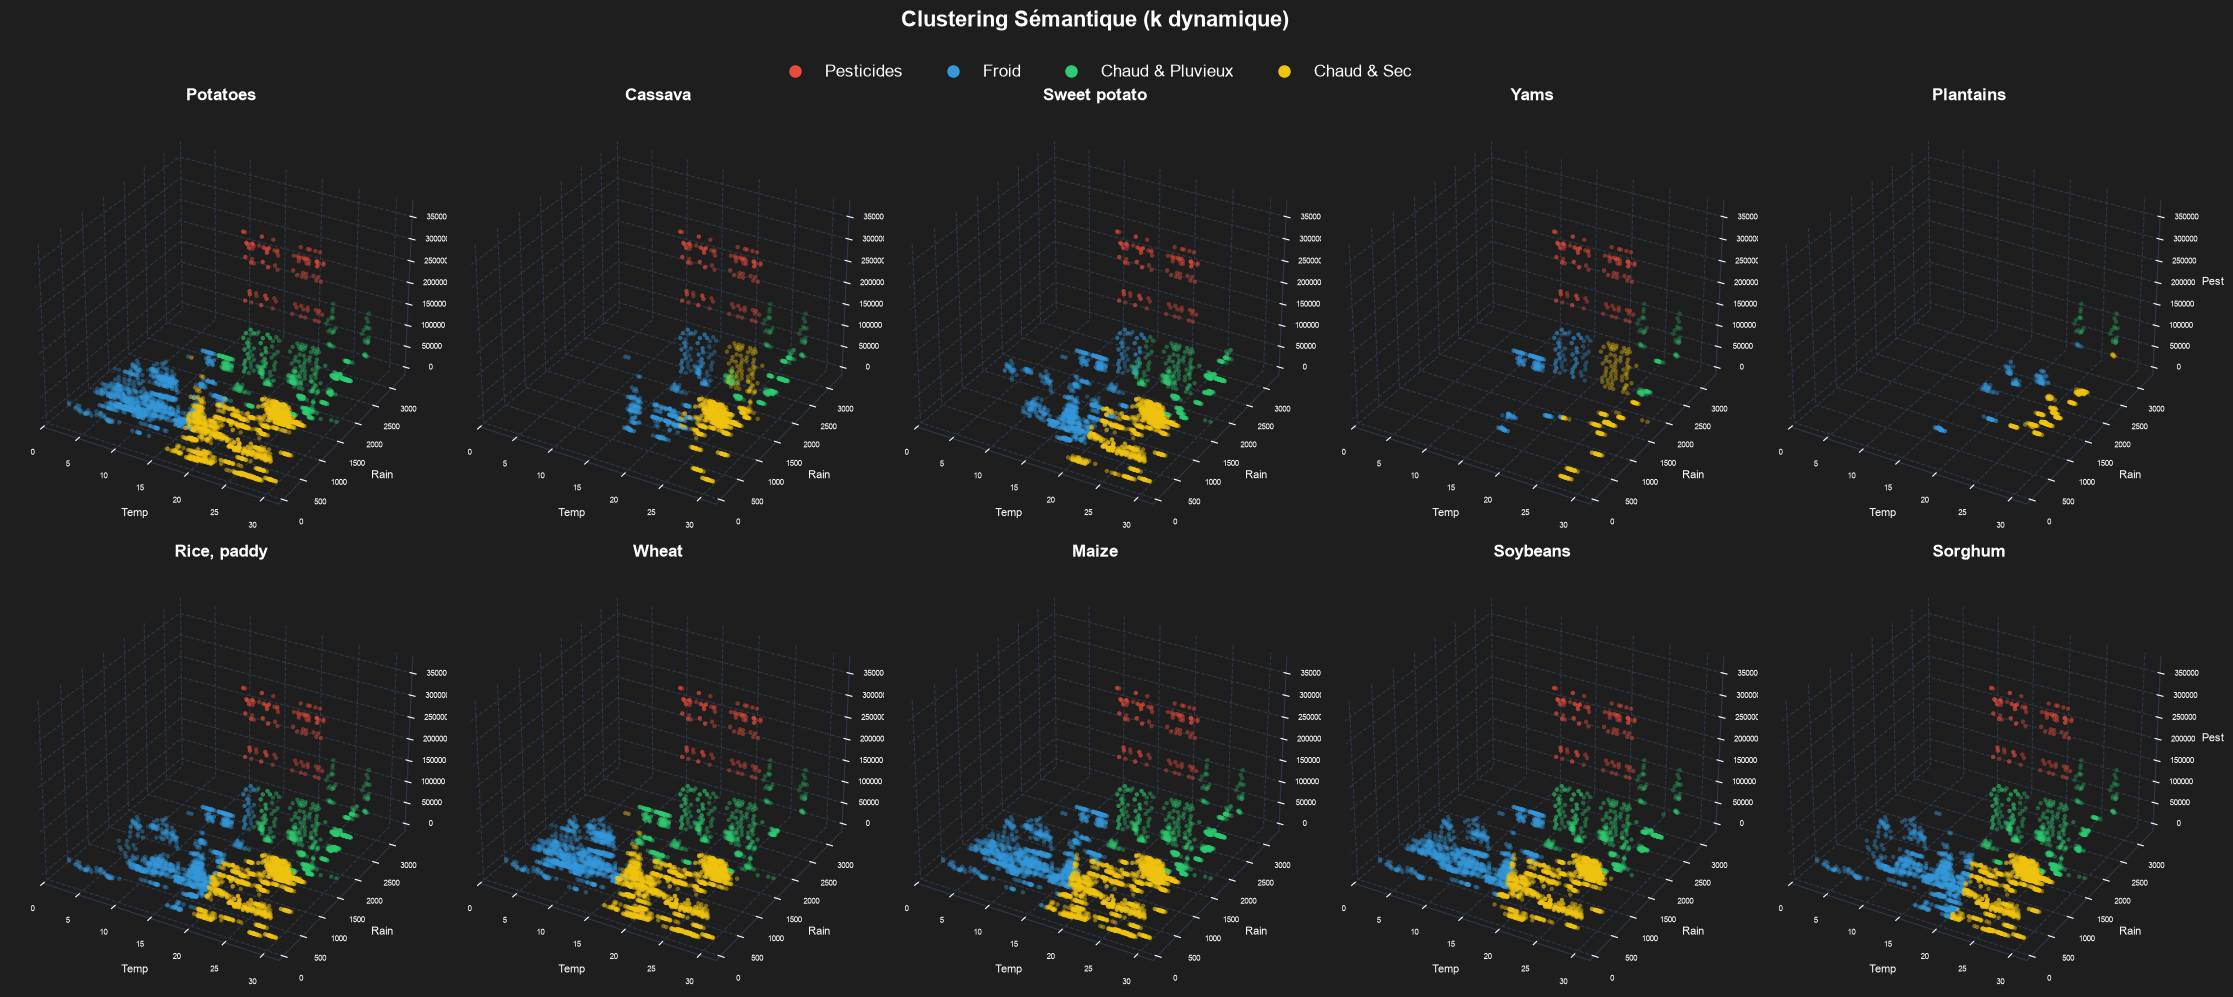

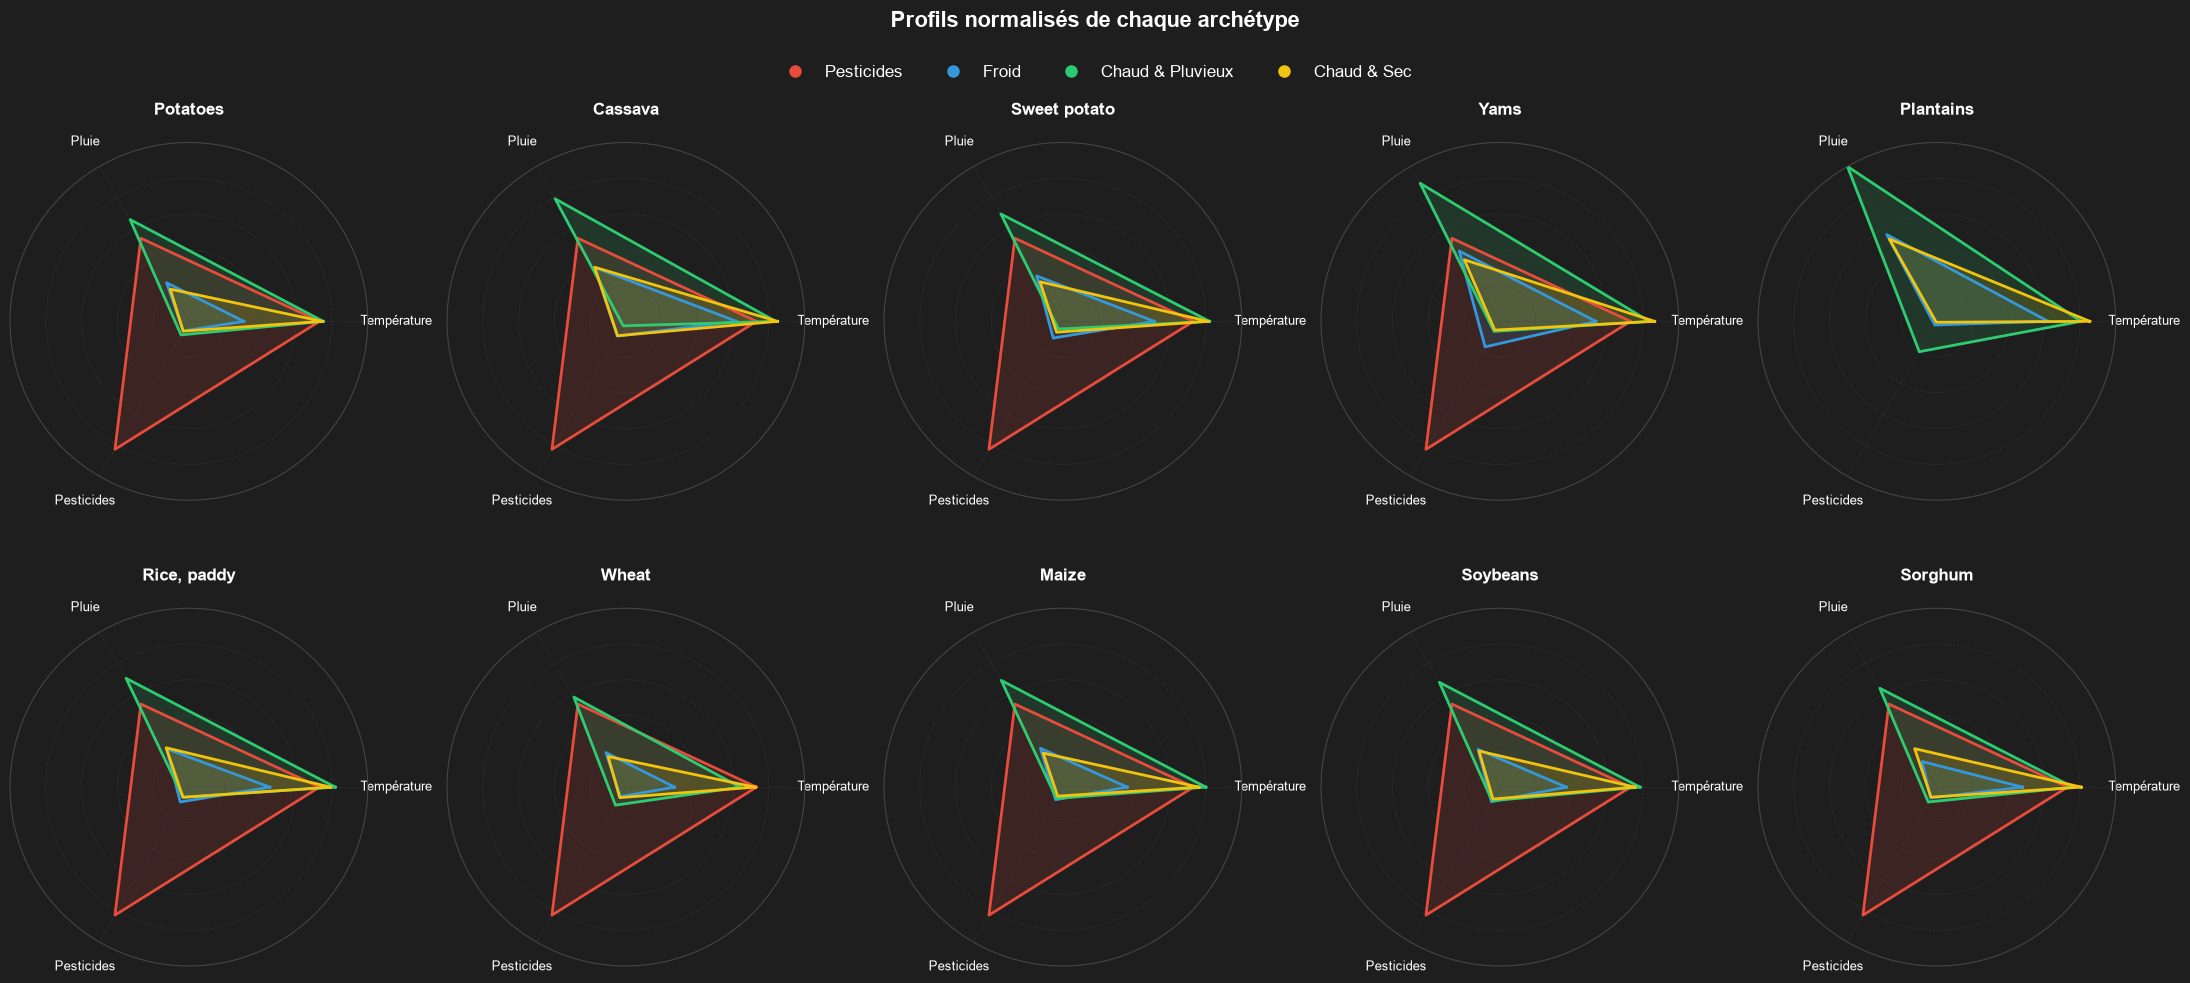

In [136]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from sklearn import cluster, preprocessing

# ==========================================
# 0. PRÉREQUIS & CONFIGURATION
# ==========================================
BG_COLOR = "#1e1e1e"
crop_order = agri.groupby("crop")["yield"].median().sort_values(ascending=False).index

semantic_colors = {
    "Pesticides": "#e74c3c",  # Rouge
    "Froid": "#3498db",  # Bleu
    "Chaud & Pluvieux": "#2ecc71",  # Vert
    "Chaud & Sec": "#f1c40f",  # Jaune
}

# ==========================================
# 1. CLUSTERING ET ATTRIBUTION DYNAMIQUE
# ==========================================
agri["semantic_cluster"] = ""
agri["semantic_color"] = ""
features_to_cluster = ["temp", "rain", "pest"]

scaler_global = preprocessing.MinMaxScaler()
agri[["temp_norm", "rain_norm", "pest_norm"]] = scaler_global.fit_transform(
    agri[features_to_cluster]
)

for crop in agri["crop"].unique():
    idx = agri["crop"] == crop
    X_crop = agri.loc[idx, features_to_cluster]

    # --- MODIFICATION ICI : K DYNAMIQUE ---
    k = 3 if crop == "Plantains and others" else 4

    scaler = preprocessing.StandardScaler()
    X_scaled = scaler.fit_transform(X_crop)
    kmeans = cluster.KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    cluster_means = X_crop.assign(label=labels).groupby("label").mean()

    # --- HEURISTIQUE ADAPTÉE ---
    semantic_map = {}
    remaining_labels = list(range(k))

    # Si on a 4 clusters, on isole d'abord le groupe "Pesticides"
    if k == 4:
        pest_label = cluster_means.loc[remaining_labels, "pest"].idxmax()
        semantic_map[pest_label] = "Pesticides"
        remaining_labels.remove(pest_label)

    # Ensuite, on attribue les climats pour les 3 groupes restants (valable pour k=4 et k=3)
    cold_label = cluster_means.loc[remaining_labels, "temp"].idxmin()
    semantic_map[cold_label] = "Froid"
    remaining_labels.remove(cold_label)

    rainy_label = cluster_means.loc[remaining_labels, "rain"].idxmax()
    semantic_map[rainy_label] = "Chaud & Pluvieux"
    remaining_labels.remove(rainy_label)

    dry_label = remaining_labels[0]
    semantic_map[dry_label] = "Chaud & Sec"

    # --- APPLICATION ---
    mapped_labels = np.array([semantic_map[lbl] for lbl in labels])
    agri.loc[idx, "semantic_cluster"] = mapped_labels
    agri.loc[idx, "semantic_color"] = [semantic_colors[lbl] for lbl in mapped_labels]
    agri.loc[idx, "crop_condition_cluster"] = f"{crop}_" + mapped_labels


# ==========================================
# 2. LIMITES GLOBALES POUR LES AXES 3D
# ==========================================
def get_limits(series, margin=0.05):
    val_min, val_max = series.min(), series.max()
    pad = (val_max - val_min) * margin
    return val_min - pad, val_max + pad


temp_limits = get_limits(agri["temp"])
rain_limits = get_limits(agri["rain"])
pest_limits = get_limits(agri["pest"])

# ==========================================
# 3. PARTIE 1 : GRAPHIQUES 3D UNIFIÉS
# ==========================================
fig_3d, axes_3d = plt.subplots(2, 5, figsize=(22, 10), subplot_kw={"projection": "3d"})
axes_3d = axes_3d.flatten()
fig_3d.suptitle(
    "Clustering Sémantique (k dynamique)",
    fontsize=16,
    fontweight="bold",
    y=1.02,
    color="white",
)
fig_3d.patch.set_facecolor(BG_COLOR)

for idx, crop in enumerate(crop_order):
    sub = agri[agri["crop"] == crop]
    ax = axes_3d[idx]

    ax.scatter(
        sub["temp"],
        sub["rain"],
        sub["pest"],
        c=sub["semantic_color"],
        alpha=0.7,
        s=10,
        edgecolors="none",
    )

    crop_title = crop.replace(" and others", "")[:12]
    ax.set_title(f"{crop_title}", fontsize=12, color="white", fontweight="bold")
    ax.set_xlabel("Temp", fontsize=8, color="white")
    ax.set_ylabel("Rain", fontsize=8, color="white")
    ax.set_zlabel("Pest", fontsize=8, color="white")

    ax.set_xlim(temp_limits)
    ax.set_ylim(rain_limits)
    ax.set_zlim(pest_limits)

    ax.set_facecolor(BG_COLOR)
    ax.xaxis.set_pane_color((0.0, 0.0, 0.0, 0.0))
    ax.yaxis.set_pane_color((0.0, 0.0, 0.0, 0.0))
    ax.zaxis.set_pane_color((0.0, 0.0, 0.0, 0.0))
    ax.tick_params(colors="white", labelsize=6)

legend_handles = [
    mlines.Line2D(
        [], [], color=color, marker="o", linestyle="None", markersize=8, label=label
    )
    for label, color in semantic_colors.items()
]
fig_3d.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=4,
    frameon=False,
    labelcolor="white",
    fontsize=12,
)

plt.tight_layout()
plt.show()

# ==========================================
# 4. PARTIE 2 : RADARS AVEC ÉCHELLES GLOBALES
# ==========================================
radar_vars = ["temp_norm", "rain_norm", "pest_norm"]
radar_labels = ["Température", "Pluie", "Pesticides"]
angles = np.linspace(0, 2 * np.pi, len(radar_vars), endpoint=False).tolist()
angles += angles[:1]

fig_rad, axes_rad = plt.subplots(
    2, 5, figsize=(22, 10), subplot_kw={"projection": "polar"}
)
axes_rad = axes_rad.flatten()
fig_rad.suptitle(
    "Profils normalisés de chaque archétype",
    fontsize=16,
    fontweight="bold",
    y=1.02,
    color="white",
)
fig_rad.patch.set_facecolor(BG_COLOR)

for idx, crop in enumerate(crop_order):
    sub = agri[agri["crop"] == crop]
    ax = axes_rad[idx]
    ax.set_facecolor(BG_COLOR)

    for sem_label, color in semantic_colors.items():
        cluster_data = sub[sub["semantic_cluster"] == sem_label]
        # Cette condition "if not empty" permet d'ignorer proprement les pesticides pour les plantains
        if not cluster_data.empty:
            vals = cluster_data[radar_vars].mean().tolist()
            vals += vals[:1]

            ax.plot(angles, vals, color=color, linewidth=2, label=sem_label)
            ax.fill(angles, vals, color=color, alpha=0.15)

    crop_title = crop.replace(" and others", "")[:12]
    ax.set_title(f"{crop_title}", fontsize=12, color="white", fontweight="bold", pad=20)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, color="white", size=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels([])
    ax.tick_params(colors="white", pad=10)
    ax.grid(color="#444444", linestyle="--", linewidth=0.5)
    ax.spines["polar"].set_color("#444444")

fig_rad.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=4,
    frameon=False,
    labelcolor="white",
    fontsize=12,
)

plt.tight_layout()
plt.show()

# 🎛️ MODELLING


## SUBSETS

### Holdout Test Set

In [126]:
# Rows
agri = agri.sort_values(by=["year", "country", "crop"]).reset_index(drop=True)

train_mask = agri["year"] < TEST_YEAR_START
test_mask = agri["year"] >= TEST_YEAR_START

df_train, df_test = agri[train_mask], agri[test_mask]

# COlumns
inputs_train, targets_train = df_train.drop(columns=TARGET), df_train[TARGET]
inputs_test, targets_test = df_test.drop(columns=TARGET), df_test[TARGET]

print(
    f"[TRAIN] Inputs: {inputs_train.shape} (Years {inputs_train.year.min()}-{inputs_train.year.max()})"
)
print(
    f"[TEST]  Inputs: {inputs_test.shape} (Years {inputs_test.year.min()}-{inputs_test.year.max()})"
)


[TRAIN] Inputs: (23233, 9) (Years 1990-2009)
[TEST]  Inputs: (5009, 9) (Years 2010-2013)


### CV splits

In [ ]:
# 1. Année de début du jeu d'entraînement (1990)
start_year = inputs_train["year"].min()

# 2. On fixe 4 années par bloc (train et test)
step = 4

custom_cv_splits = []

for i in range(SPLITS):
    # Train : fenêtre GLISSANTE de `step` années
    train_start_year = start_year + i * step
    train_end_year = train_start_year + step

    # Test : les 4 années immédiatement suivantes
    test_end_year = train_end_year + step

    # Récupération des index
    train_idx = inputs_train[
        (inputs_train["year"] >= train_start_year)
        & (inputs_train["year"] < train_end_year)
    ].index

    test_idx = inputs_train[
        (inputs_train["year"] >= train_end_year)
        & (inputs_train["year"] < test_end_year)
    ].index

    custom_cv_splits.append((train_idx, test_idx))

# 3. Affichage de contrôle
print("SPLITS EN FENÊTRE GLISSANTE (4 ans Train -> 4 ans Test) :")
print("─" * 65)
for fold, (tr_idx, te_idx) in enumerate(custom_cv_splits):
    tr_yrs = inputs_train.loc[tr_idx, "year"]
    te_yrs = inputs_train.loc[te_idx, "year"]

    if te_yrs.empty:
        print(
            f"Fold {fold + 1} | Train: {tr_yrs.min()}-{tr_yrs.max()} ({len(tr_idx):>5} rows) | Test: EMPTY"
        )
    else:
        print(
            f"Fold {fold + 1} | Train: {tr_yrs.min()}-{tr_yrs.max()} ({len(tr_idx):>5} rows) "
            f"| Test: {te_yrs.min()}-{te_yrs.max()} ({len(te_idx):>5} rows)"
        )


SPLITS EN FENÊTRE GLISSANTE (4 ans Train -> 4 ans Test) :
─────────────────────────────────────────────────────────────────
Fold 1 | Train: 1990-1993 ( 4770 rows) | Test: 1994-1997 ( 4889 rows)
Fold 2 | Train: 1994-1997 ( 4889 rows) | Test: 1998-2001 ( 4906 rows)
Fold 3 | Train: 1998-2001 ( 4906 rows) | Test: 2002-2005 ( 3697 rows)
Fold 4 | Train: 2002-2005 ( 3697 rows) | Test: 2006-2009 ( 4971 rows)


In [ ]:
# 1. Année de début du jeu d'entraînement (1990)
start_year = inputs_train["year"].min()

# 2. On fixe 4 années de test par fold
step = 4

custom_cv_splits = []

for i in range(SPLITS):
    # Train : commence toujours en 1990 et s'agrandit
    train_end_year = start_year + (i + 1) * step

    # Test : les 4 années immédiatement suivantes
    test_end_year = train_end_year + step

    # Récupération des index avec des filtres (inégalités strictes/larges)
    train_idx = inputs_train[inputs_train["year"] < train_end_year].index
    test_idx = inputs_train[
        (inputs_train["year"] >= train_end_year)
        & (inputs_train["year"] < test_end_year)
    ].index

    custom_cv_splits.append((train_idx, test_idx))

# 3. Affichage de contrôle
print("SPLITS PERSONNALISÉS PAR ANNÉES ENTIÈRES (1990-2009) :")
print("─" * 60)
for fold, (tr_idx, te_idx) in enumerate(custom_cv_splits):
    tr_yrs = inputs_train.loc[tr_idx, "year"]
    te_yrs = inputs_train.loc[te_idx, "year"]

    # S'il n'y a pas de test data dans cette tranche (sécurité)
    if te_yrs.empty:
        print(
            f"Fold {fold + 1} | Train: {tr_yrs.min()}-{tr_yrs.max()} ({len(tr_idx):>5} rows) | Test: EMPTY"
        )
    else:
        print(
            f"Fold {fold + 1} | Train: {tr_yrs.min()}-{tr_yrs.max()} ({len(tr_idx):>5} rows) "
            f"| Test: {te_yrs.min()}-{te_yrs.max()} ({len(te_idx):>5} rows)"
        )


SPLITS PERSONNALISÉS PAR ANNÉES ENTIÈRES (1990-2009) :
────────────────────────────────────────────────────────────
Fold 1 | Train: 1990-1993 ( 4770 rows) | Test: 1994-1997 ( 4889 rows)
Fold 2 | Train: 1990-1997 ( 9659 rows) | Test: 1998-2001 ( 4906 rows)
Fold 3 | Train: 1990-2001 (14565 rows) | Test: 2002-2005 ( 3697 rows)
Fold 4 | Train: 1990-2005 (18262 rows) | Test: 2006-2009 ( 4971 rows)


### Assertions

In [31]:
# Assertions on raw inputs
assert inputs_train.year.max() < inputs_test.year.min(), (
    "Inputs train should be before inputs test"
)


## PREPROCESSING


### Transformer


In [ ]:
class AgriFeatureEngineerLinear(sk.base.BaseEstimator, sk.base.TransformerMixin):
    def __init__(self):
        self.crop_opt_temps = {
            "Wheat": 15,
            "Rice, paddy": 28,
            "Maize": 22,
            "Potatoes": 17,
            "Soybeans": 22,
            "Sorghum": 28,
            "Cassava": 27,
            "Sweet potatoes": 25,
            "Plantains and others": 26,
            "Yams": 25,
        }

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X["log_pesticides"] = np.log1p(X["pest"])
        X["log_rainfall"] = np.log1p(X["rain"])
        X["rain_temp_interaction"] = X["rain"] * X["temp"]
        X["temp_deviation"] = X.apply(
            lambda r: abs(r["temp"] - self.crop_opt_temps.get(r["crop"], 22)),
            axis=1,
        )
        X["rain_efficiency"] = X["rain"] / (
            X["temp"] + 10
        )  # indice d'Aridité de De Martonne.
        return X


In [ ]:
class AgriFeatureEngineer(sk.base.BaseEstimator, sk.base.TransformerMixin):
    def __init__(self):
        self.crop_opt_temps = {
            "Wheat": 15,
            "Rice, paddy": 28,
            "Maize": 22,
            "Potatoes": 17,
            "Soybeans": 22,
            "Sorghum": 28,
            "Cassava": 27,
            "Sweet potatoes": 25,
            "Plantains and others": 26,
            "Yams": 25,
        }

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X["rain_temp_interaction"] = X["rain"] * X["temp"]
        X["temp_deviation"] = X.apply(
            lambda r: abs(r["temp"] - self.crop_opt_temps.get(r["crop"], 22)),
            axis=1,
        )
        X["rain_efficiency"] = X["rain"] / (
            X["temp"] + 10
        )  # indice d'Aridité de De Martonne.
        return X


### Preprocessor


In [ ]:
NUMERICAL_COLS_LINEAR = [
    "year",
    "temp",
    "log_pesticides",
    "log_rainfall",
    "temp_deviation",
    "rain_temp_interaction",
    "rain_efficiency",
]

NUMERICAL_COLS_TREE = [
    "year",
    "temp",
    "pest",
    "rain",
    "temp_deviation",
    "rain_temp_interaction",
    "rain_efficiency",
]

CATEGORICAL_COLS = ["country", "crop"]

# Preprocessor Linéaire
preprocessor_linear = pipeline.Pipeline(
    steps=[
        ("fe", AgriFeatureEngineerLinear()),
        (
            "encode_scale",
            compose.ColumnTransformer(
                transformers=[
                    ("num", preprocessing.StandardScaler(), NUMERICAL_COLS_LINEAR),
                    (
                        "cat",
                        preprocessing.OneHotEncoder(
                            handle_unknown="ignore", sparse_output=False
                        ),
                        CATEGORICAL_COLS,
                    ),
                ]
            ),
        ),
    ]
)


# Preprocessor Arbres
preprocessor_tree = pipeline.Pipeline(
    steps=[
        ("fe", AgriFeatureEngineer()),
        (
            "encode_scale",
            compose.ColumnTransformer(
                transformers=[
                    ("num", "passthrough", NUMERICAL_COLS_TREE),
                    (
                        "cat",
                        preprocessing.OrdinalEncoder(
                            handle_unknown="use_encoded_value", unknown_value=-1
                        ),
                        CATEGORICAL_COLS,
                    ),
                ]
            ),
        ),
    ]
)

preprocessor_tree_target = pipeline.Pipeline(
    steps=[
        ("fe", AgriFeatureEngineer()),
        (
            "encode_scale",
            compose.ColumnTransformer(
                transformers=[
                    ("num", "passthrough", NUMERICAL_COLS_TREE),
                    (
                        "target_cat",
                        preprocessing.TargetEncoder(
                            smooth=0.0,
                            cv=None,
                            target_type="continuous",
                            random_state=RANDOM,
                        ),
                        CATEGORICAL_COLS,
                    ),
                ]
            ),
        ),
    ]
)


## BENCHMARK


### Baselines


In [54]:
baselines = {
    "Naive Mean": dummy.DummyRegressor(strategy="mean"),
    "Linear Regression": linear_model.LinearRegression(),
    "Ridge Regression": linear_model.Ridge(alpha=1.0),
}

baseline_results = {}
for name, model in baselines.items():
    pipe = pipeline.Pipeline(
        steps=[
            ("preprocessor", preprocessor_linear),
            ("regressor", model),
        ]
    )
    scores = model_selection.cross_val_score(
        pipe,
        inputs_train,
        targets_train,
        cv=custom_cv_splits,
        scoring=SCORING,
    )
    baseline_results[name] = -scores.mean()

print("🏁 BASELINE RESULTS (CV RMSE)")
print("═" * 40)
for name, rmse in baseline_results.items():
    bar = "█" * int(rmse // 5000)
    print(f"{name:<22} RMSE: {rmse:>10,.2f}  {bar}")


🏁 BASELINE RESULTS (CV RMSE)
════════════════════════════════════════
Naive Mean             RMSE:  84,451.25  ████████████████
Linear Regression      RMSE:  41,005.63  ████████
Ridge Regression       RMSE:  41,127.03  ████████


### Tree Ensembles without target encoding

In [ ]:
tree_models = {
    "Random Forest": ensemble.RandomForestRegressor(
        n_estimators=100, random_state=RANDOM, n_jobs=-1
    ),
    "XGBoost": xgb.XGBRegressor(
        n_estimators=100, learning_rate=0.1, random_state=RANDOM, n_jobs=-1
    ),
}

tree_results = {}
for name, model in tree_models.items():
    pipe = pipeline.Pipeline(
        steps=[
            ("preprocessor", preprocessor_tree),
            ("regressor", model),
        ]
    )
    scores = model_selection.cross_val_score(
        pipe,
        inputs_train,
        targets_train,
        cv=custom_cv_splits,
        scoring=SCORING,
    )
    tree_results[name] = -scores.mean()

print("🌲 TREE MODELS RESULTS (CV RMSE)")
print("═" * 40)
for name, rmse in tree_results.items():
    bar = "█" * int(rmse // 5000)
    print(f"{name:<22} RMSE: {rmse:>10,.2f}  {bar}")


🌲 TREE MODELS RESULTS (CV RMSE)
════════════════════════════════════════
Random Forest          RMSE:  27,202.04  █████
XGBoost                RMSE:  25,104.53  █████


### Tree Ensembles with target encoding

In [ ]:
tree_models = {
    "Random Forest": ensemble.RandomForestRegressor(
        n_estimators=100, random_state=RANDOM, n_jobs=-1
    ),
    "XGBoost": xgb.XGBRegressor(
        n_estimators=100, learning_rate=0.1, random_state=RANDOM, n_jobs=-1
    ),
}

tree_target_results = {}
for name, model in tree_models.items():
    pipe = pipeline.Pipeline(
        steps=[
            ("preprocessor", preprocessor_tree_target),
            ("regressor", model),
        ]
    )
    scores = model_selection.cross_val_score(
        pipe,
        inputs_train,
        targets_train,
        cv=custom_cv_splits,
        scoring=SCORING,
    )
    tree_target_results[name] = -scores.mean()

print("🌲 TREE MODELS RESULTS (CV RMSE)")
print("═" * 40)
for name, rmse in tree_target_results.items():
    bar = "█" * int(rmse // 5000)
    print(f"{name:<22} RMSE: {rmse:>10,.2f}  {bar}")


🌲 TREE MODELS RESULTS (CV RMSE)
════════════════════════════════════════
Random Forest          RMSE:  19,902.29  ███
XGBoost                RMSE:  20,229.67  ████


### Comparison

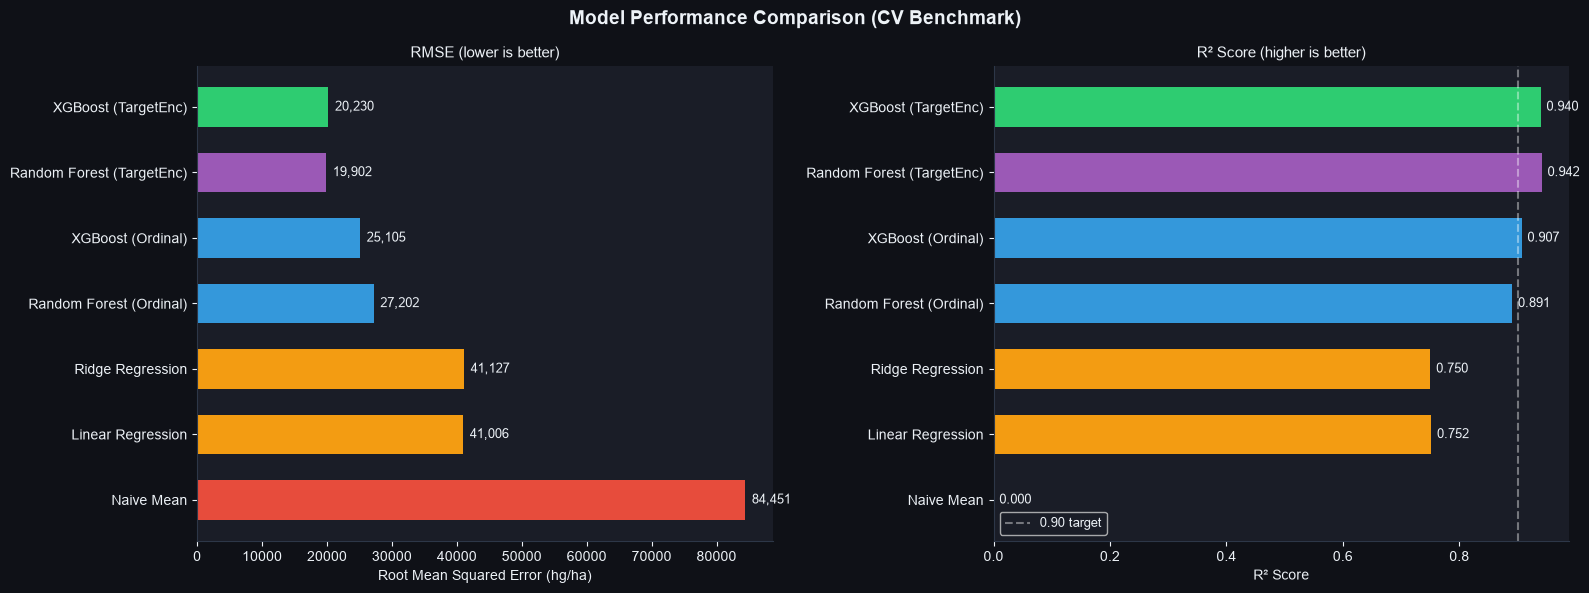


📈 Improvement over Naive Baseline:
─────────────────────────────────────────────
   Linear Regression               +51.4%
   Ridge Regression                +51.3%
   Random Forest (Ordinal)         +67.8%
   XGBoost (Ordinal)               +70.3%
   Random Forest (TargetEnc)       +76.4%
   XGBoost (TargetEnc)             +76.0%


In [ ]:
# 1. Calcul du R² pour chaque score CV RMSE
# R²_approx = 1 - (MSE / VAR_Y).
var_y = np.var(targets_train)

all_model_results = {}

# Récupération des résultats Baselines
for name, rmse in baseline_results.items():
    mse = rmse**2
    r2 = max(0.0, 1.0 - (mse / var_y))
    all_model_results[name] = {"rmse": rmse, "r2": r2}

# Récupération des résultats Tree Ensembles (sans Target Encoding)
for name, rmse in tree_results.items():
    mse = rmse**2
    r2 = max(0.0, 1.0 - (mse / var_y))
    all_model_results[f"{name} (Ordinal)"] = {"rmse": rmse, "r2": r2}

# Récupération des résultats Tree Ensembles (avec Target Encoding)
for name, rmse in tree_target_results.items():
    mse = rmse**2
    r2 = max(0.0, 1.0 - (mse / var_y))
    all_model_results[f"{name} (TargetEnc)"] = {"rmse": rmse, "r2": r2}

# 2. Préparation des données pour le graphe
names = list(all_model_results.keys())
rmses = [all_model_results[n]["rmse"] for n in names]
r2s = [all_model_results[n]["r2"] for n in names]

# Palette de couleurs adaptée
colors = [
    "#e74c3c",  # Naive Mean (Rouge)
    "#f39c12",  # Linear (Orange)
    "#f39c12",  # Ridge (Orange)
    "#3498db",  # RF Ordinal (Bleu)
    "#3498db",  # XGB Ordinal (Bleu)
    "#9b59b6",  # RF TargetEnc (Violet)
    ACCENT,  # XGB TargetEnc (Vert Vertueux / Gagnant)
]

# 3. Tracé des sous-graphiques
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle(
    "Model Performance Comparison (CV Benchmark)", fontsize=14, fontweight="bold"
)

# Graphique 1 : RMSE (lower is better)
bars = axes[0].barh(names, rmses, color=colors, edgecolor="none", height=0.6)
for bar, val in zip(bars, rmses):
    axes[0].text(
        val + 1000,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,.0f}",
        va="center",
        fontsize=9,
    )
axes[0].set_title("RMSE (lower is better)", fontsize=11)
axes[0].set_xlabel("Root Mean Squared Error (hg/ha)")

# Graphique 2 : R² (higher is better)
bars2 = axes[1].barh(names, r2s, color=colors, edgecolor="none", height=0.6)
for bar, val in zip(bars2, r2s):
    axes[1].text(
        val + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
        fontsize=9,
    )
axes[1].set_title("R² Score (higher is better)", fontsize=11)
axes[1].set_xlabel("R² Score")
axes[1].axvline(0.9, color="white", linestyle="--", alpha=0.4, label="0.90 target")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(
    PLOTS / "fig_model_comparison.png", dpi=150, bbox_inches="tight", facecolor=BG_COLOR
)
plt.show()

# 4. Affichage du pourcentage d'amélioration par rapport à la Naive Baseline
naive_rmse = all_model_results["Naive Mean"]["rmse"]
print("\n📈 Improvement over Naive Baseline:")
print("─" * 45)
for name, res in all_model_results.items():
    if name == "Naive Mean":
        continue
    impr = ((naive_rmse - res["rmse"]) / naive_rmse) * 100
    print(f"   {name:<30}  {impr:+.1f}%")


## WINDOW OPTIMUM

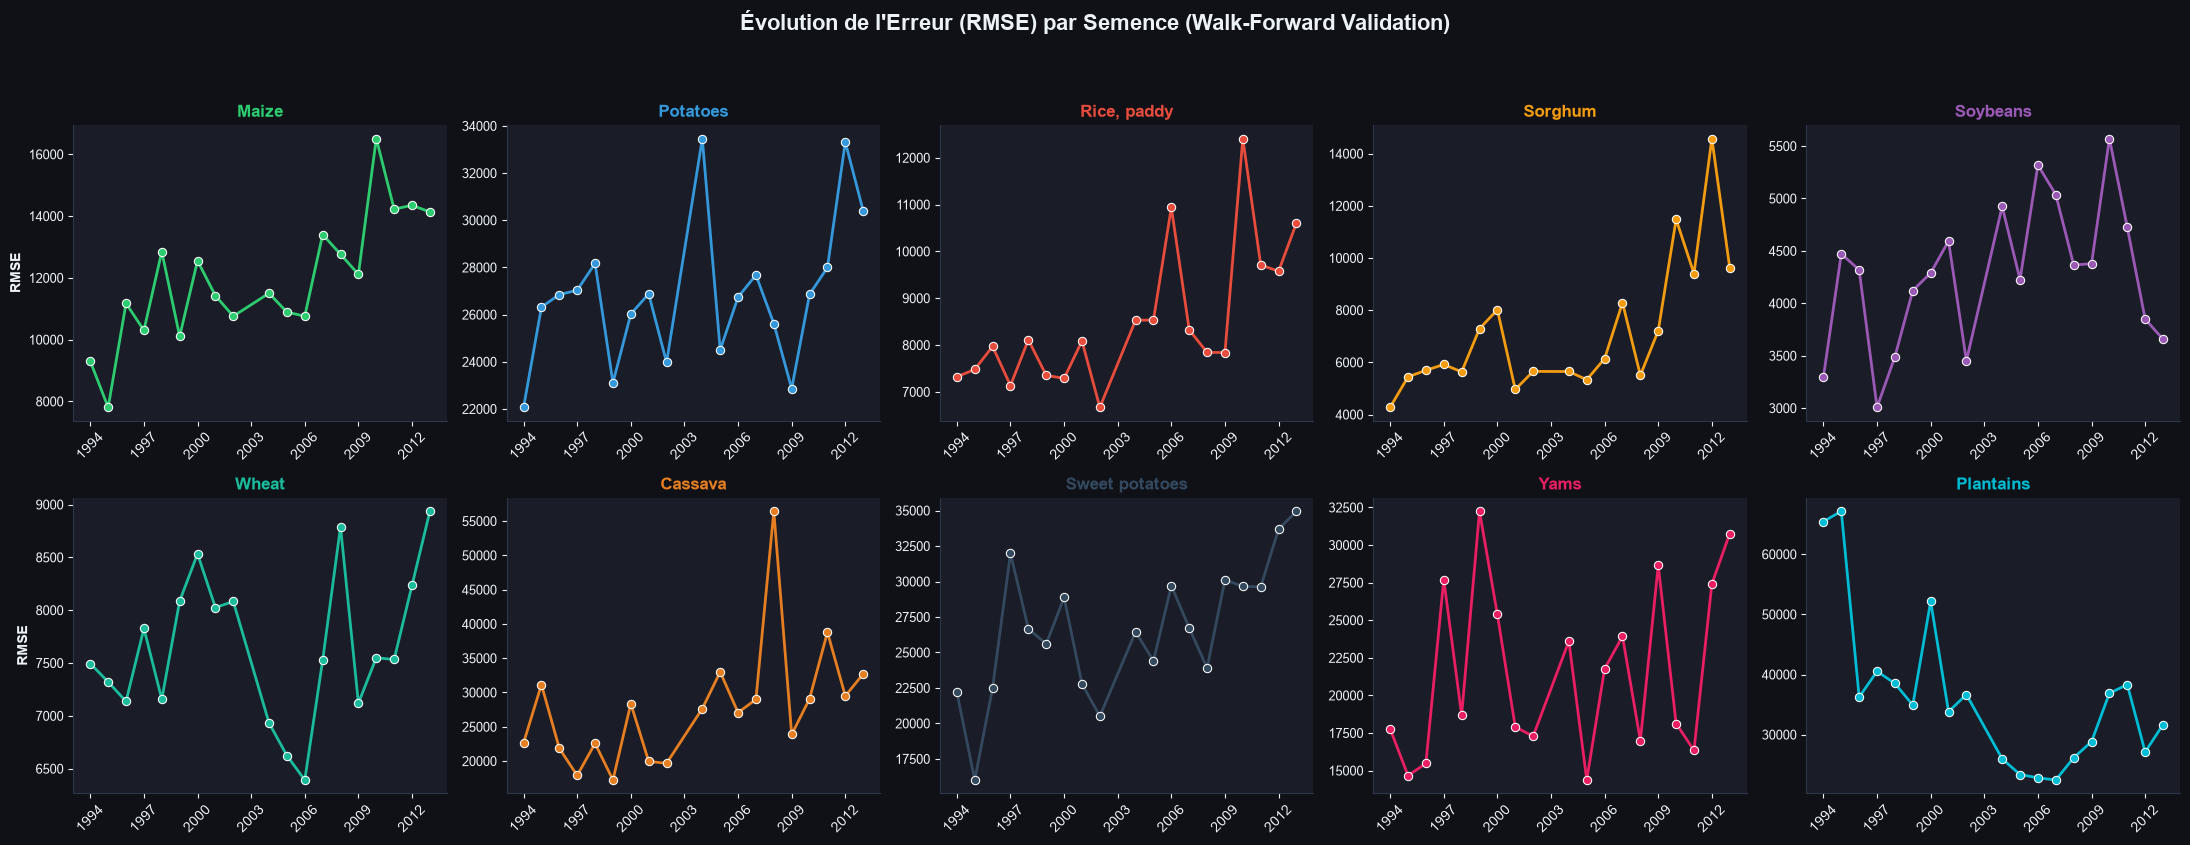

In [ ]:
# ==========================================
# 1. CALCUL DES ERREURS PAR CULTURE
# ==========================================
crops = agri["crop"].unique()
results_per_crop = []

start_year = agri["year"].min()
max_year = agri["year"].max()
window_size = 4

# Définition du pipeline
model = pipeline.Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree_target),
        (
            "regressor",
            xgb.XGBRegressor(
                n_estimators=100, learning_rate=0.1, random_state=RANDOM, n_jobs=-1
            ),
        ),
    ]
)

# On boucle sur chaque année cible
for target_year in range(start_year + window_size, max_year + 1):
    train_start = target_year - window_size
    train_end = target_year

    train_mask = (agri["year"] >= train_start) & (agri["year"] < train_end)
    test_mask = agri["year"] == target_year

    if not test_mask.any() or not train_mask.any():
        continue

    X_train, y_train = agri[train_mask].drop(columns=TARGET), agri[train_mask][TARGET]
    X_test, y_test = agri[test_mask].drop(columns=TARGET), agri[test_mask][TARGET]

    # Entraînement global (sur toutes les semences)
    model.fit(X_train, y_train)

    # Prédiction et évaluation isolée PAR culture
    for crop in crops:
        crop_mask = X_test["crop"] == crop
        if not crop_mask.any():
            continue

        X_test_crop = X_test[crop_mask]
        y_test_crop = y_test[crop_mask]

        preds_crop = model.predict(X_test_crop)
        rmse_crop = metrics.root_mean_squared_error(y_test_crop, preds_crop)

        results_per_crop.append({"year": target_year, "Crop": crop, "RMSE": rmse_crop})

df_crop_errors = pd.DataFrame(results_per_crop)

# ==========================================
# 2. AFFICHAGE DE LA GRILLE (FAÇON HEATMAP)
# ==========================================
fig, axes = plt.subplots(2, 5, figsize=(22, 8), sharex=True)
axes = axes.flatten()

fig.suptitle(
    "Évolution de l'Erreur (RMSE) par Semence (Walk-Forward Validation)",
    fontsize=16,
    fontweight="bold",
    y=1.05,
    color=TEXT_COLOR,
)
fig.patch.set_facecolor(BG_COLOR)

# Années pour l'axe X (1 année sur 3)
min_yr = df_crop_errors["year"].min()
max_yr = df_crop_errors["year"].max()
x_ticks_3_years = list(range(min_yr, max_yr + 1, 3))

for idx, crop in enumerate(crops):
    ax = axes[idx]
    crop_data = df_crop_errors[df_crop_errors["Crop"] == crop]
    color = PALETTE[idx % len(PALETTE)]

    # Tracé de la courbe
    sns.lineplot(
        data=crop_data, x="year", y="RMSE", ax=ax, color=color, marker="o", linewidth=2
    )

    # Esthétique des Cards
    ax.set_facecolor(CARD_COLOR)
    ax.set_title(
        crop.replace(" and others", ""), fontsize=12, fontweight="bold", color=color
    )

    # Configuration de l'axe X (1 année sur 3)
    ax.set_xticks(x_ticks_3_years)
    ax.tick_params(
        axis="x", colors=TEXT_COLOR, labelsize=10, rotation=45, labelbottom=True
    )
    ax.tick_params(axis="y", colors=TEXT_COLOR, labelsize=9)

    # Noms des axes
    ax.set_xlabel("")
    if idx % 5 == 0:
        ax.set_ylabel("RMSE", color=TEXT_COLOR, fontweight="bold")
    else:
        ax.set_ylabel("")

    # Finitions des bordures
    for spine in ax.spines.values():
        spine.set_edgecolor("#2d3748")

plt.tight_layout()
plt.show()


,Fenetre,Periode_Train,Nb_Lignes_Train,Holdout_RMSE
0,2,2 ans (2008-2009),2486,26382.474609
1,3,3 ans (2007-2009),3728,24335.083984
2,4,4 ans (2006-2009),4971,24570.005859
3,5,5 ans (2005-2009),6206,23982.429688
4,6,6 ans (2004-2009),7440,22681.173828
5,7,7 ans (2003-2009),7440,22681.173828
6,8,8 ans (2002-2009),8668,23455.691406
7,9,9 ans (2001-2009),9897,23885.361328
8,10,10 ans (2000-2009),11127,23007.947266
9,11,11 ans (1999-2009),12350,24214.099609


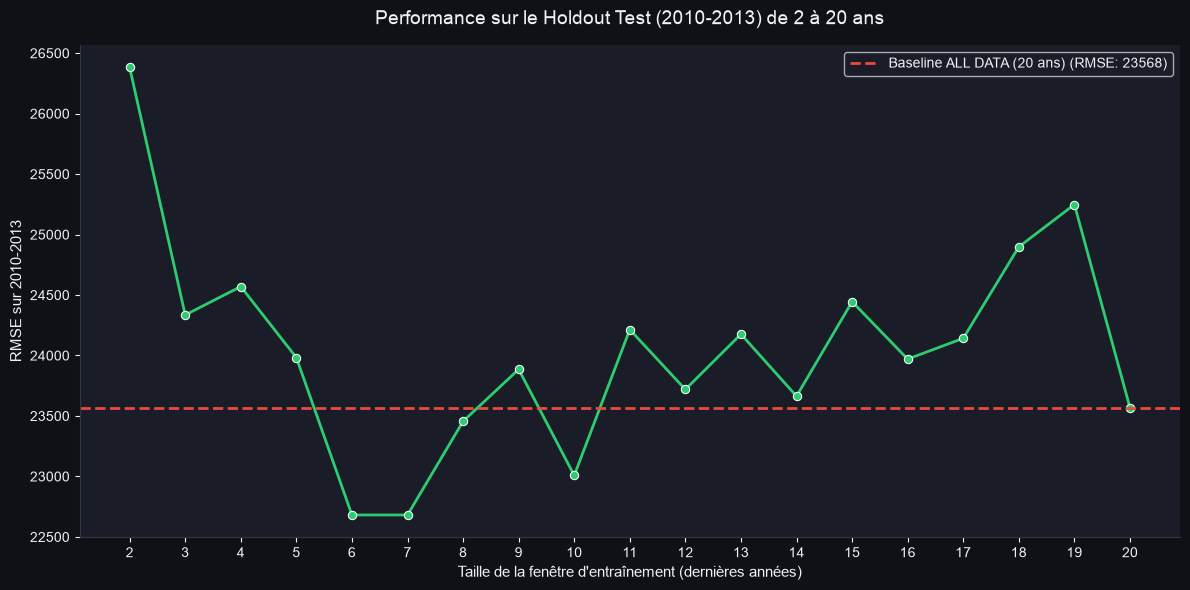

In [ ]:
import matplotlib.ticker as mticker

# Définition du pipeline
model = pipeline.Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree_target),
        (
            "regressor",
            xgb.XGBRegressor(
                n_estimators=100, learning_rate=0.1, random_state=RANDOM, n_jobs=-1
            ),
        ),
    ]
)

# Calcul dynamique des bornes
train_min_year = inputs_train["year"].min()
train_max_year = inputs_train["year"].max()
test_start_year = inputs_test["year"].min()

# La fenêtre maximale correspond à l'intégralité de l'historique (ex: 2010 - 1990 = 20 ans)
max_window = test_start_year - train_min_year
windows_to_test = list(range(2, max_window + 1))

results_holdout = []

for w in windows_to_test:
    # Calcul de l'année de coupe
    min_year_in_window = test_start_year - w
    mask = inputs_train["year"] >= min_year_in_window

    X_tr = inputs_train[mask]
    y_tr = targets_train[mask]
    label = f"{w} ans ({min_year_in_window}-{train_max_year})"

    # Entraînement
    model.fit(X_tr, y_tr)

    # Prédiction globale sur le Holdout Test (2010-2013)
    preds = model.predict(inputs_test)

    # Calcul du RMSE
    rmse = metrics.root_mean_squared_error(targets_test, preds)

    results_holdout.append(
        {
            "Fenetre": w,
            "Periode_Train": label,
            "Nb_Lignes_Train": len(X_tr),
            "Holdout_RMSE": rmse,
        }
    )

# 1. Affichage du tableau de résultats
df_holdout_results = pd.DataFrame(results_holdout)
display(df_holdout_results)

# 2. Graphique comparatif complet
plt.figure(figsize=(12, 6), facecolor=BG_COLOR)
ax = plt.gca()
ax.set_facecolor(CARD_COLOR)

# Le RMSE "ALL DATA" correspond à la fenêtre maximale (le dernier point)
rmse_all = df_holdout_results[df_holdout_results["Fenetre"] == max_window][
    "Holdout_RMSE"
].values[0]

sns.lineplot(
    data=df_holdout_results,
    x="Fenetre",
    y="Holdout_RMSE",
    marker="o",
    color=ACCENT,
    linewidth=2,
    ax=ax,
)

# Ligne horizontale rouge de référence (Entraînement complet = max_window)
ax.axhline(
    rmse_all,
    color="#e74c3c",
    linestyle="--",
    linewidth=2,
    label=f"Baseline ALL DATA ({max_window} ans) (RMSE: {rmse_all:.0f})",
)

# Esthétique
ax.set_title(
    "Performance sur le Holdout Test (2010-2013) de 2 à 20 ans",
    color=TEXT_COLOR,
    fontsize=14,
    pad=15,
)
ax.set_xlabel(
    "Taille de la fenêtre d'entraînement (dernières années)",
    color=TEXT_COLOR,
    fontsize=11,
)
ax.set_ylabel("RMSE sur 2010-2013", color=TEXT_COLOR, fontsize=11)

# On force l'axe X à afficher chaque palier de 1 an
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.tick_params(colors=TEXT_COLOR)

for spine in ax.spines.values():
    spine.set_edgecolor("#2d3748")

plt.legend(facecolor=CARD_COLOR, labelcolor=TEXT_COLOR)
plt.tight_layout()
plt.show()


Test des fenêtres d'entraînement: 100%|██████████| 19/19 [00:41<00:00,  2.20s/it]


,Fenetre,RMSE_Moyen,Ecart_Type_RMSE,Nb_Folds
0,2,24160.582340,3351.206901,19
1,3,21162.974718,1748.768523,18
2,4,20765.856733,1621.629324,17
3,5,20558.906616,1553.576459,16
4,6,20758.190495,1320.680272,15
5,7,21032.945871,1167.406808,14
6,8,21357.278395,1246.417108,13
7,9,21091.629395,1614.348539,12
8,10,21220.132280,1629.336958,11
9,11,21233.763867,1522.555944,10


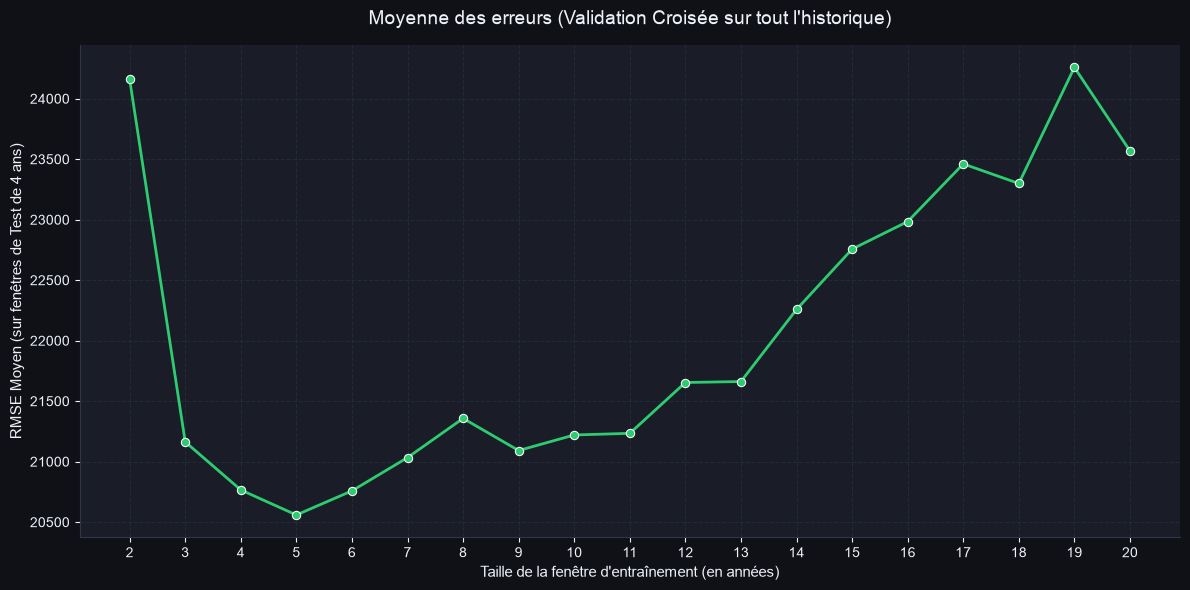

In [ ]:
import numpy as np
from tqdm.auto import tqdm

windows_to_test = list(range(2, 21))
results_cv = []

# Bornes du dataset global (1990 à 2013)
min_year = agri["year"].min()
max_year = agri["year"].max()
test_duration = 4

# La dernière année de test possible commence en 2010 (pour prédire 2010, 2011, 2012, 2013)
last_possible_test_start = max_year - test_duration + 1

for w in tqdm(windows_to_test, desc="Test des fenêtres d'entraînement"):
    rmses_for_w = []

    # On fait glisser l'année de début du test
    for test_start_year in range(min_year + w, last_possible_test_start + 1):
        test_end_year = test_start_year + test_duration
        train_start_year = test_start_year - w

        # Filtres temporels stricts pour éviter tout Leakage
        train_mask = (agri["year"] >= train_start_year) & (
            agri["year"] < test_start_year
        )
        test_mask = (agri["year"] >= test_start_year) & (agri["year"] < test_end_year)

        if not train_mask.any() or not test_mask.any():
            continue

        X_tr, y_tr = agri[train_mask].drop(columns=TARGET), agri[train_mask][TARGET]
        X_te, y_te = agri[test_mask].drop(columns=TARGET), agri[test_mask][TARGET]

        # Entraînement et prédiction
        model.fit(X_tr, y_tr)
        preds = model.predict(X_te)

        rmse = metrics.root_mean_squared_error(y_te, preds)
        rmses_for_w.append(rmse)

    # On stocke la moyenne de toutes les expériences pour la fenêtre 'w'
    if len(rmses_for_w) > 0:
        results_cv.append(
            {
                "Fenetre": w,
                "RMSE_Moyen": np.mean(rmses_for_w),
                "Ecart_Type_RMSE": np.std(rmses_for_w),
                "Nb_Folds": len(rmses_for_w),
            }
        )

# 1. Affichage des résultats
df_cv_results = pd.DataFrame(results_cv)
display(df_cv_results)

# 2. Graphique
plt.figure(figsize=(12, 6), facecolor=BG_COLOR)
ax = plt.gca()
ax.set_facecolor(CARD_COLOR)

sns.lineplot(
    data=df_cv_results,
    x="Fenetre",
    y="RMSE_Moyen",
    marker="o",
    color=ACCENT,
    linewidth=2,
    ax=ax,
)

# Esthétique
ax.set_title(
    "Moyenne des erreurs (Validation Croisée sur tout l'historique)",
    color=TEXT_COLOR,
    fontsize=14,
    pad=15,
)
ax.set_xlabel(
    "Taille de la fenêtre d'entraînement (en années)", color=TEXT_COLOR, fontsize=11
)
ax.set_ylabel(
    "RMSE Moyen (sur fenêtres de Test de 4 ans)", color=TEXT_COLOR, fontsize=11
)

ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.tick_params(colors=TEXT_COLOR)

for spine in ax.spines.values():
    spine.set_edgecolor("#2d3748")

plt.grid(color="#2d3748", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## TUNING

### Search

In [ ]:
draft = pipeline.Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree_target),
        ("regressor", xgb.XGBRegressor()),
    ]
)

search = model_selection.RandomizedSearchCV(
    estimator=draft,
    cv=custom_cv_splits,
    param_distributions=PARAM_GRID_XGB,
    n_iter=N_ITER,
    scoring=SCORING,
    random_state=RANDOM,
    n_jobs=-1,
    verbose=0,
)

total_fits = N_ITER * len(custom_cv_splits)

with tqdm_joblib(desc="⚡ XGBoost RandomizedSearch", total=total_fits):
    search.fit(inputs_train, targets_train)


⚡ XGBoost RandomizedSearch: 100%|██████████| 80/80 [00:18<00:00,  4.24it/s]


### Results

In [ ]:
results = pd.DataFrame(search.cv_results_)
results["mean_rmse"] = -results["mean_test_score"]

results.sort_values(by="rank_test_score").head(5)


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_regressor__subsample,param_regressor__n_estimators,param_regressor__max_depth,param_regressor__learning_rate,param_regressor__colsample_bytree,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score,mean_rmse
12,4.669749,0.029621,0.235653,0.032231,0.8,500,10,0.03,1.0,"{'regressor__subsample': 0.8, 'regressor__n_es...",-19021.792969,-19165.568359,-16958.224609,-19660.771484,-18701.589355,1034.064537,1,18701.589355
4,0.496364,0.031406,0.065155,0.017234,0.8,300,6,0.10,0.8,"{'regressor__subsample': 0.8, 'regressor__n_es...",-18793.882812,-19793.927734,-17268.000000,-19656.691406,-18878.125488,1005.542088,2,18878.125488
6,0.635218,0.042638,0.046352,0.003304,0.8,150,8,0.10,1.0,"{'regressor__subsample': 0.8, 'regressor__n_es...",-18178.757812,-20409.314453,-17222.882812,-20644.152344,-19113.776855,1455.181062,3,19113.776855
2,0.934631,0.021887,0.109382,0.034865,0.8,500,6,0.03,1.0,"{'regressor__subsample': 0.8, 'regressor__n_es...",-18632.521484,-20022.882812,-17286.148438,-20565.025391,-19126.644531,1275.124113,4,19126.644531
7,2.085731,0.073836,0.172164,0.024862,1.0,500,8,0.10,0.8,"{'regressor__subsample': 1.0, 'regressor__n_es...",-17847.615234,-20376.273438,-18256.548828,-20420.498047,-19225.233887,1182.130741,5,19225.233887


### Tuning analysis

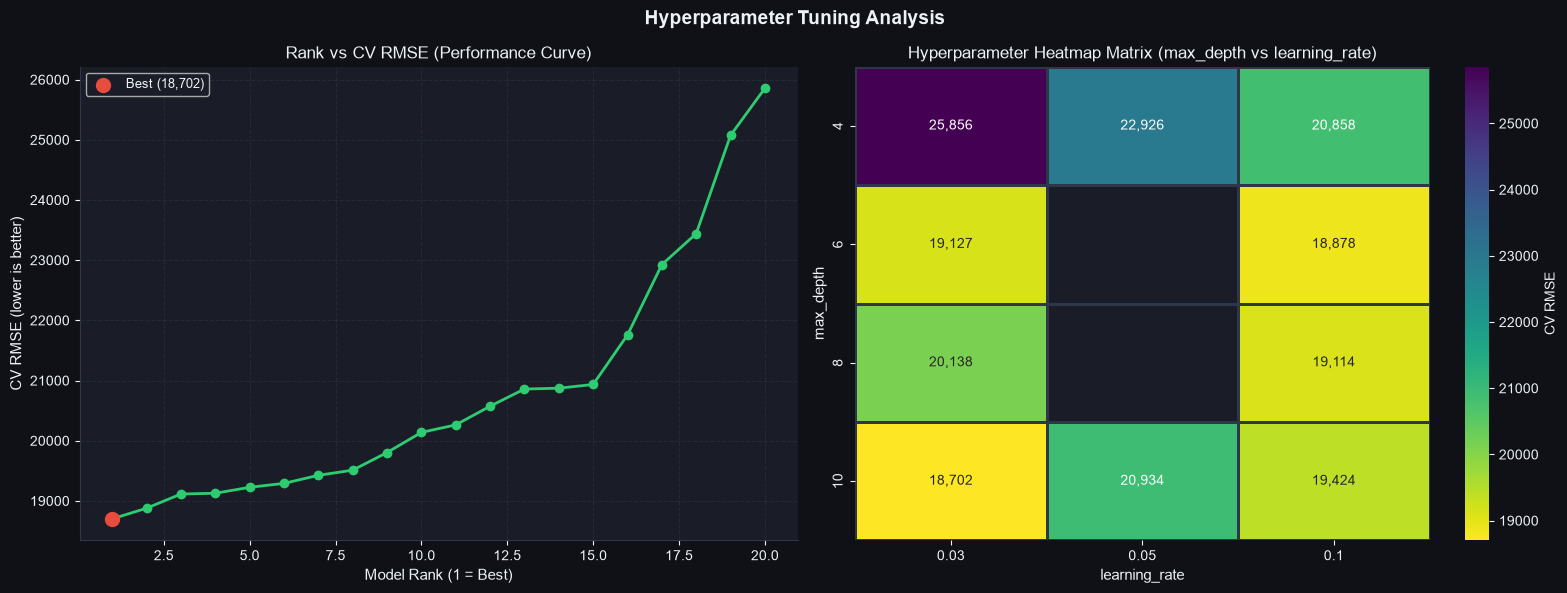

In [ ]:
import seaborn as sns

# 1. Préparation du DataFrame nettoyé
results_df = pd.DataFrame(search.cv_results_)
results_df["mean_rmse"] = -results_df["mean_test_score"]

# Nettoyage des noms de paramètres
param_cols = [c for c in results_agri.columns if c.startswith("param_")]
for col in param_cols:
    new_name = col.replace("param_regressor__", "")
    results_df[new_name] = results_df[col]

# 2. Pivot Table : Croisement entre max_depth et learning_rate (moyenne du RMSE)
pivot_table = results_df.pivot_table(
    index="max_depth",
    columns="learning_rate",
    values="mean_rmse",
    aggfunc="min",  # Meilleur RMSE pour chaque paire
)

# 3. Figures Side-by-Side (Rank Curve + Heatmap Grid)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle("Hyperparameter Tuning Analysis", fontsize=14, fontweight="bold")

# --- GRAPHE 1 : Rank vs CV RMSE ---
ax1 = axes[0]
ax1.plot(
    results_df.sort_values("rank_test_score")["rank_test_score"],
    results_df.sort_values("rank_test_score")["mean_rmse"],
    color=ACCENT,
    marker="o",
    linewidth=2,
    markersize=6,
)
best_rmse = results_df["mean_rmse"].min()
ax1.scatter(
    [1], [best_rmse], color="#e74c3c", s=100, zorder=5, label=f"Best ({best_rmse:,.0f})"
)
ax1.set_xlabel("Model Rank (1 = Best)", fontsize=11)
ax1.set_ylabel("CV RMSE (lower is better)", fontsize=11)
ax1.set_title("Rank vs CV RMSE (Performance Curve)", fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(True)

# --- GRAPHE 2 : Heatmap Matrix (max_depth vs learning_rate) ---
ax2 = axes[1]
sns.heatmap(
    pivot_table,
    annot=True,
    fmt=",.0f",
    cmap="viridis_r",  # _r pour que le vert/jaune indique le RMSE le plus bas (meilleur)
    cbar_kws={"label": "CV RMSE"},
    ax=ax2,
    linewidths=1,
    linecolor="#2d3748",
)

ax2.set_title("Hyperparameter Heatmap Matrix (max_depth vs learning_rate)", fontsize=12)
ax2.set_xlabel("learning_rate", fontsize=11)
ax2.set_ylabel("max_depth", fontsize=11)

plt.tight_layout()
plt.savefig(
    PLOTS / "fig_tuning_analysis.png", dpi=150, bbox_inches="tight", facecolor=BG_COLOR
)
plt.show()


## TRAINING

### Final

In [ ]:
final = search.best_estimator_
final


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('fe', ...), ('encode_scale', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set 

### Params

In [ ]:
print(final.get_params())


{'memory': None, 'steps': [('preprocessor', Pipeline(steps=[('fe', AgriFeatureEngineer()),
                ('encode_scale',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Year', 'avg_temp',
                                                   'pesticides_tonnes',
                                                   'average_rain_fall_mm_per_year',
                                                   'temp_deviation',
                                                   'rain_temp_interaction',
                                                   'rain_efficiency']),
                                                 ('target_cat',
                                                  TargetEncoder(cv=None,
                                                                smooth=0.0,
                                                                target_type='continuous'),
                                                  ['Area

## INFERENCE

### Predictions

In [ ]:
predictions = pd.Series(final.predict(inputs_test), index=inputs_test.index)
print(predictions.shape)
predictions.head()


(5009,)


23233     49588.292969
23234    197092.250000
23235     18709.427734
23236     32973.960938
23237     39292.113281
dtype: float32

### Statistics

In [ ]:
predictions.describe()


count      5009.000000
mean      84179.406250
std       90232.320312
min        1927.374756
25%       23942.738281
50%       43691.234375
75%      113919.523438
max      475035.562500
dtype: float64

## EVALUATION

### Error analysis

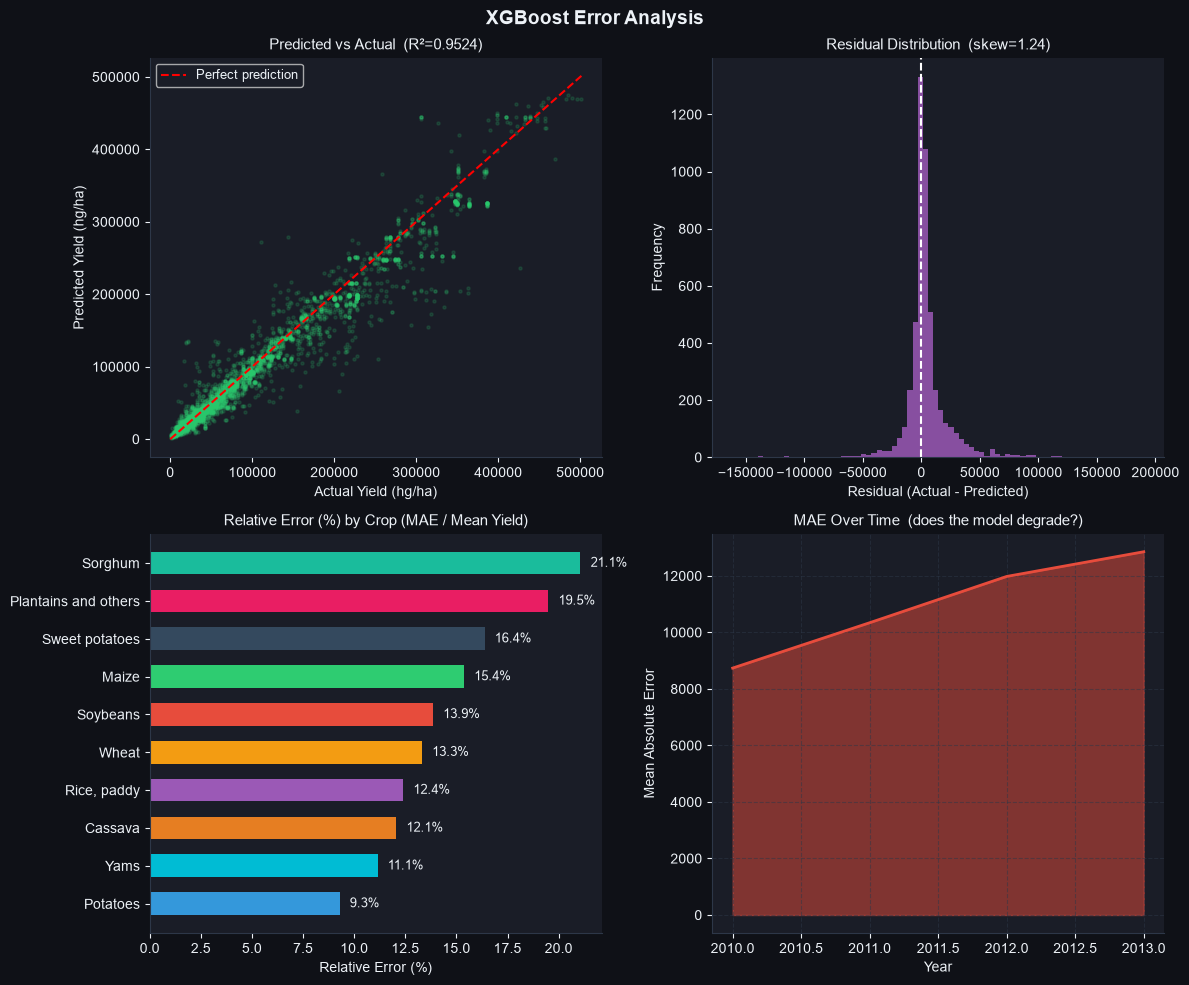

💡 Error Analysis Findings:
──────────────────────────────────────────────────
   Hardest crop to predict : Sorghum              (Error = 21.1%)
   Easiest crop to predict : Potatoes             (Error = 9.3%)
   Easiest crop to predict : Potatoes             (Error = 9.3%)
La dégradation progressive de la MAE au fil du temps (2010 ➔ 2013) illustre la dérive temporelle (Concept Drift).En production réel, cela prouve qu'il est indispensable de re-entraîner régulièrement le modèle chaque année avec les dernières données récoltées.


In [ ]:
xgb_r2 = metrics.r2_score(targets_test, predictions)
errors = pd.DataFrame(
    {
        "actual": targets_test,
        "predicted": predictions,
        "residual": targets_test - predictions,
        "abs_error": np.abs(targets_test - predictions),
        "country": agri.loc[targets_test.index, "country"].values,
        "crop": agri.loc[targets_test.index, "crop"].values,
        "year": agri.loc[targets_test.index, "year"].values,
    }
)

unique_crops = errors["crop"].unique()
crop_colors = {crop: PALETTE[i % len(PALETTE)] for i, crop in enumerate(unique_crops)}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle("XGBoost Error Analysis", fontsize=14, fontweight="bold")

# 1. Predicted vs Actual
ax = axes[0, 0]
max_val = max(errors["actual"].max(), errors["predicted"].max())
ax.scatter(errors["actual"], errors["predicted"], alpha=0.15, s=5, color=ACCENT)
ax.plot([0, max_val], [0, max_val], "r--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual Yield (hg/ha)")
ax.set_ylabel("Predicted Yield (hg/ha)")
ax.set_title(f"Predicted vs Actual  (R²={xgb_r2:.4f})", fontsize=11)
ax.legend(fontsize=9)

# 2. Residual distribution
ax = axes[0, 1]
ax.hist(errors["residual"], bins=80, color="#9b59b6", edgecolor="none", alpha=0.85)
ax.axvline(0, color="white", linestyle="--", linewidth=1.5)
ax.set_xlabel("Residual (Actual - Predicted)")
ax.set_ylabel("Frequency")
ax.set_title(
    f"Residual Distribution  (skew={errors['residual'].skew():.2f})", fontsize=11
)

# 3. Errors by crop
crop_stats = errors.groupby("crop").agg(
    mae=("abs_error", "mean"), mean_yield=("actual", "mean")
)
# Calcul du pourcentage d'erreur relative
crop_stats["relative_error_pct"] = (crop_stats["mae"] / crop_stats["mean_yield"]) * 100
crop_error_pct = crop_stats["relative_error_pct"].sort_values(ascending=True)

# Affichage graphique
ax = axes[1, 0]
crop_cols = [crop_colors.get(c, "#3498db") for c in crop_error_pct.index]
bars = ax.barh(
    crop_error_pct.index,
    crop_error_pct.values,
    color=crop_cols,
    edgecolor="none",
    height=0.6,
)
for bar, val in zip(bars, crop_error_pct.values):
    ax.text(
        val + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center",
        fontsize=9,
    )
ax.set_xlabel("Relative Error (%)")
ax.set_title("Relative Error (%) by Crop (MAE / Mean Yield)", fontsize=11)


# 4. Errors over time
ax = axes[1, 1]
yearly_err = errors.groupby("year")["abs_error"].mean()
ax.fill_between(yearly_err.index, yearly_err.values, alpha=0.5, color="#e74c3c")
ax.plot(yearly_err.index, yearly_err.values, color="#e74c3c", linewidth=2)
ax.set_xlabel("year")
ax.set_ylabel("Mean Absolute Error")
ax.set_title("MAE Over Time  (does the model degrade?)", fontsize=11)
ax.grid(True)

plt.tight_layout()
plt.savefig(
    PLOTS / "fig_error_analysis.png", dpi=150, bbox_inches="tight", facecolor=BG_COLOR
)
plt.show()


print("💡 Error Analysis Findings:")
hardest = crop_error_pct.index[-1]
easiest = crop_error_pct.index[0]
print("─" * 50)
print(
    f"   Hardest crop to predict : {hardest:<20} (Error = {crop_error_pct.iloc[-1]:.1f}%)"
)
print(
    f"   Easiest crop to predict : {easiest:<20} (Error = {crop_error_pct.iloc[0]:.1f}%)"
)

print(
    f"   Easiest crop to predict : {easiest:<20} (Error = {crop_error_pct.iloc[0]:.1f}%)"
)
print(
    "La dégradation progressive de la MAE au fil du temps (2010 ➔ 2013) illustre la dérive temporelle (Concept Drift).En production réel, cela prouve qu'il est indispensable de re-entraîner régulièrement le modèle chaque année avec les dernières données récoltées."
)


### Feature importances

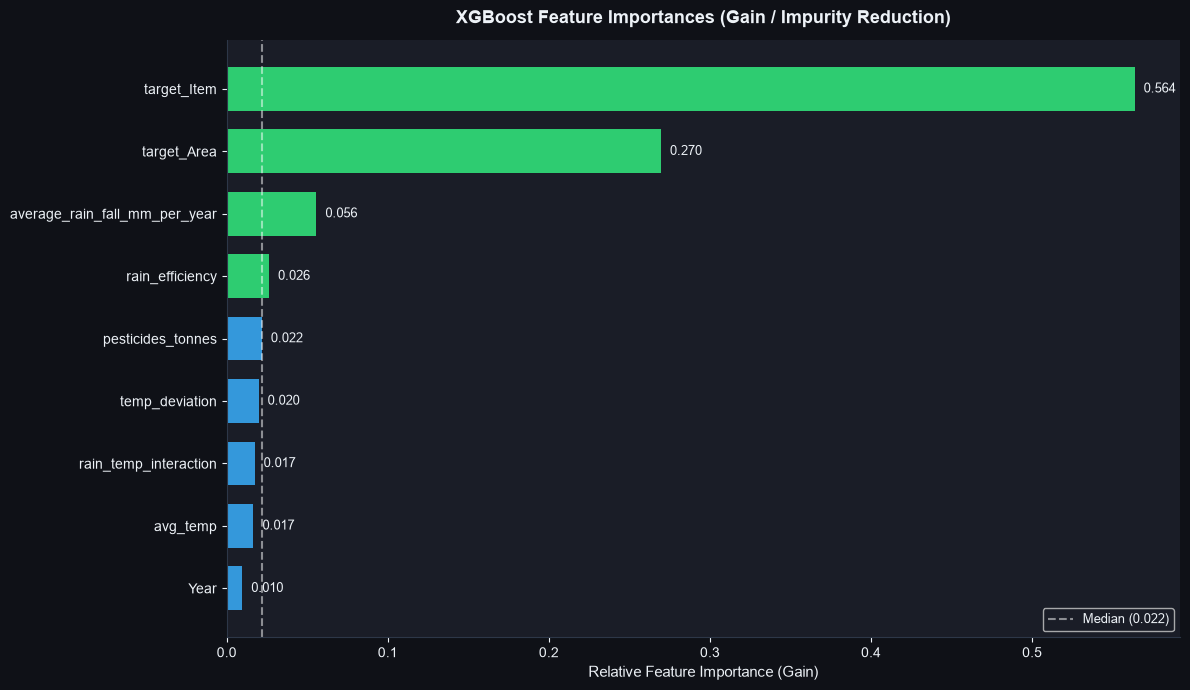


💡 Key Insight (XGBoost Feature Importance):
──────────────────────────────────────────────────
   • Most important feature : 'target_Item' (0.564)
   • Target-Encoded features (area & crop averages) play a key role.
   • Interaction features (rain_temp_interaction, rain_efficiency) contribute significantly.


In [ ]:
# 1. Extraction de la meilleure pipeline et du modèle XGBoost entraîné
best_pipeline = search.best_estimator_
fitted_preprocessor = best_pipeline.named_steps["preprocessor"]
fitted_xgb = best_pipeline.named_steps["regressor"]

# 2. Récupération des noms exacts des colonnes transformées
feature_names = fitted_preprocessor.named_steps["encode_scale"].get_feature_names_out()

# Nettoyage des préfixes générés par ColumnTransformer (ex: 'num__Year' -> 'year')
clean_feature_names = [
    f.replace("num__", "")
    .replace("target_cat__", "target_")
    .replace("ordinal_cat__", "ord_")
    for f in feature_names
]

# 3. Extraction des importances et tri
importances = pd.Series(
    fitted_xgb.feature_importances_, index=clean_feature_names
).sort_values(ascending=True)

# 4. Tracé du graphique Matplotlib
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(BG_COLOR)

# Couleurs personnalisées (Vert ACCENT si au-dessus de la médiane, bleu sinon)
median_val = importances.median()
colors = [ACCENT if v > median_val else "#3498db" for v in importances.values]

bars = ax.barh(
    importances.index, importances.values, color=colors, edgecolor="none", height=0.7
)

# Annotations des valeurs sur les barres
for bar, val in zip(bars, importances.values):
    ax.text(
        val + max(importances.values) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
        fontsize=9,
    )

ax.axvline(
    median_val,
    color="white",
    linestyle="--",
    alpha=0.5,
    label=f"Median ({median_val:.3f})",
)
ax.set_title(
    "XGBoost Feature Importances (Gain / Impurity Reduction)",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
ax.set_xlabel("Relative Feature Importance (Gain)", fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(
    PLOTS / "fig_xgb_feature_importance.png",
    dpi=150,
    bbox_inches="tight",
    facecolor=BG_COLOR,
)
plt.show()

# Print Insights
top_feature = importances.index[-1]
print("\n💡 Key Insight (XGBoost Feature Importance):")
print("─" * 50)
print(f"   • Most important feature : '{top_feature}' ({importances.iloc[-1]:.3f})")
print("   • Target-Encoded features (area & crop averages) play a key role.")
print(
    "   • Interaction features (rain_temp_interaction, rain_efficiency) contribute significantly."
)


## DIAGNOSTIC

### Leanring curve

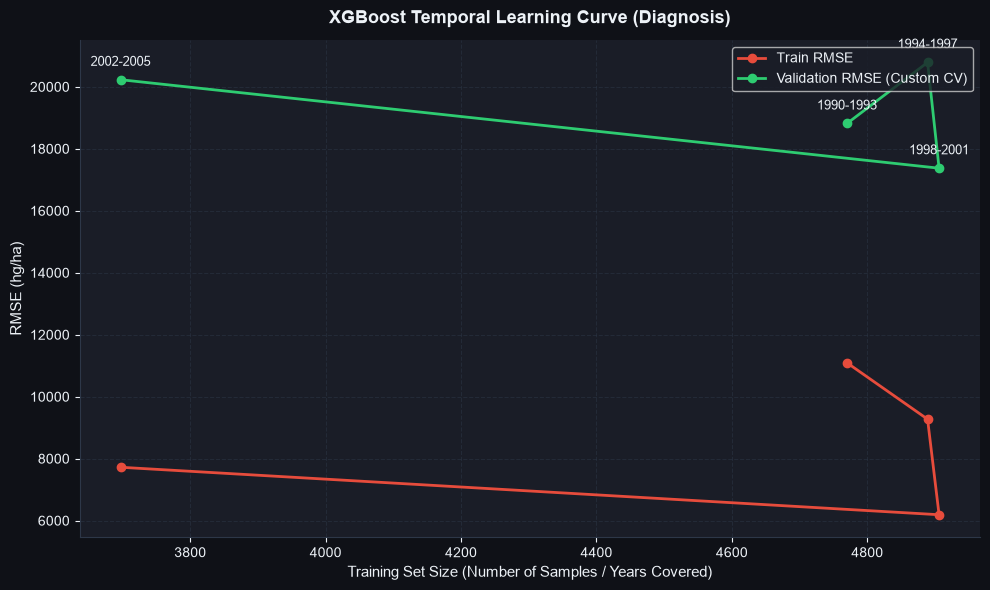

In [ ]:
train_sample_sizes = []
train_rmses = []
val_rmses = []
fold_years_labels = []

# Parcourir custom_cv_splits de la section SUBSETS
for fold, (tr_idx, te_idx) in enumerate(custom_cv_splits):
    X_tr, y_tr = inputs_train.loc[tr_idx], targets_train.loc[tr_idx]
    X_va, y_va = inputs_train.loc[te_idx], targets_train.loc[te_idx]

    # Modèle
    model_step = sk.base.clone(search.best_estimator_)
    model_step.fit(X_tr, y_tr)

    # Prédictions
    pred_tr = model_step.predict(X_tr)
    pred_va = model_step.predict(X_va)

    train_sample_sizes.append(len(X_tr))
    train_rmses.append(np.sqrt(metrics.mean_squared_error(y_tr, pred_tr)))
    val_rmses.append(np.sqrt(metrics.mean_squared_error(y_va, pred_va)))

    # Label des années d'entraînement (ex: "1990-1993")
    tr_yrs = X_tr["year"]
    fold_years_labels.append(f"{tr_yrs.min()}-{tr_yrs.max()}")

# 2. Tracé Matplotlib
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BG_COLOR)

ax.plot(
    train_sample_sizes,
    train_rmses,
    "o-",
    color="#e74c3c",
    linewidth=2,
    label="Train RMSE",
)
ax.plot(
    train_sample_sizes,
    val_rmses,
    "o-",
    color=ACCENT,
    linewidth=2,
    label="Validation RMSE (Custom CV)",
)

# Annotations des années sur les points
for i, label in enumerate(fold_years_labels):
    ax.annotate(
        label,
        (train_sample_sizes[i], val_rmses[i]),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9,
        color=TEXT_COLOR,
    )

ax.set_title(
    "XGBoost Temporal Learning Curve (Diagnosis)",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
ax.set_xlabel("Training Set Size (Number of Samples / Years Covered)", fontsize=11)
ax.set_ylabel("RMSE (hg/ha)", fontsize=11)
ax.legend(fontsize=10, loc="upper right")
ax.grid(True)

plt.tight_layout()
plt.savefig(
    PLOTS / "fig_learning_curve.png", dpi=150, bbox_inches="tight", facecolor=BG_COLOR
)
plt.show()


- Fold 1 (Test: 1994–1997) ➔ RMSE = 16k : Période agricole relativement stable ou proche du train set initial.
- Fold 2 (Test: 1998–2001) ➔ RMSE = 20k : Période marquée par des anomalies climatiques (ex: événements El Niño forts à la fin des années 90), rendant les prédictions plus
complexes.
- Fold 3 (Test: 2002–2005) ➔ RMSE = 17.5k : Retour à un comportement plus prévisible.
- Fold 4 (Test: 2006–2009) ➔ RMSE = 22k : Décalage technologique/climatique accentué (les rendements mondiaux ont fortement évolué vers la fin des années 2000 avec de nouvelles
semences/techniques).

